# Predicting Vehicle Prices Using Regression Models

## **Objectives**  
The primary goal of this project is to develop a robust regression model to predict used car prices for a reseller based on various listed features and specifications. In addition to predicting prices, the project focuses on identifying feature importance and mitigating overfitting through the application of regularisation techniques.

There can be several business objectives for this, such as:

* **Price Prediction**: Model car prices based on features like mileage, fuel type, and performance.
* **Market Analysis**: Explore trends and preferences in the used car market, by type, region, or other metrics.
* **Feature Importance**: Identify the most important factors influencing car prices (e.g., fuel type, mileage, age).

### **Tasks Overview**
The data pipeline for this task involves the following steps:  
1. **Dataset Overview**   
2. **Data Preprocessing**
3. **Data Visualisation & Exploration**
4. **Model Building**
3. **Regularisation**

## **1 Data Understanding**

| **Variable** | **Description** |
--------|--------------|
| `make_model` | The brand and model of the vehicle (e.g., 'Audi A1'). |
| `body_type` | The body style of the vehicle, such as Sedan, Compact, or Station Wagon. |
| `price`  | The listed price of the car in currency. |
| `vat`  | Indicates the VAT status for the vehicle's price (e.g., VAT deductible, Price negotiable). |
| `km` | The total mileage (in kilometers) of the vehicle, indicating its usage. |
| `Type` | Condition of the vehicle, whether it's 'Used' or 'New'.|
| `Fuel` | Type of fuel the vehicle uses, such as 'Diesel', 'Benzine', etc. |
| `Gears` | The number of gears in the vehicle's transmission. |
| `Comfort_Convenience` | Comfort and convenience features, such as 'Air conditioning', 'Leather steering wheel', 'Cruise control', and more. |
| `Entertainment_Media` | Media features available in the vehicle, including 'Bluetooth', 'MP3', 'Radio', etc. |
| `Extras` | Additional features like 'Alloy wheels', 'Sport suspension', etc.|
| `Safety_Security` | Safety features like 'ABS', 'Airbags', 'Electronic stability control', 'Isofix', etc.  |
| `age` | Age of the car (calculated based on the model year). |
| `Previous_Owners`| The number of previous owners the car has had. |
| `hp_kW` | Engine power in kilowatts (kW), indicating the performance capacity of the engine.|
| `Inspection_new` | Indicates whether the car has recently undergone an inspection (1 for yes, 0 for no). |
| `Paint_Type`| The type of paint on the car, such as 'Metallic', 'Matte', etc. |
| `Upholstery_type` | The material used for the interior upholstery, such as 'Cloth', 'Leather', etc.|
| `Gearing_Type` | The type of transmission the car uses, either 'Automatic' or 'Manual'. |
| `Displacement_cc` | The engine displacement in cubic centimeters (cc), indicating the size of the engine.|
| `Weight_kg` | The total weight of the vehicle in kilograms.|
| `Drive_chain` | The type of drivetrain, indicating whether it's 'Front' or 'Rear' wheel drive. |
| `cons_comb`  | The combined fuel consumption in liters per 100 kilometers.|

### **1.1 Data Loading**

**Importing Necessary Libraries**

In [2]:
# Importing necessary libraries

import pandas as pd

import matplotlib.pyplot as plt

#### **1.1.1**
Load the dataset

In [5]:
# Load the data

df = pd.read_csv("Car_Price_data.csv")
# Change pandas settings to show ALL columns and the FULL text inside them
pd.set_option('display.max_columns', None)  # Don't hide any columns
pd.set_option('display.max_colwidth', None) # Don't truncate text within columns
pd.set_option('display.width', 1000)        # Allow a wide display layout

# Now run head, and it will show everything!
print(df.head())

  make_model body_type  price               vat       km  Type     Fuel  Gears                                                                                                                                                                                                                                                                                          Comfort_Convenience                                                                    Entertainment_Media                                                     Extras                                                                                                                                                                                                                                                                       Safety_Security  age  Previous_Owners  hp_kW  Inspection_new Paint_Type Upholstery_type Gearing_Type  Displacement_cc  Weight_kg Drive_chain  cons_comb
0    Audi A1    Sedans  15770    VAT deductible  56013.0  Us

## **2 Analysis and Feature Engineering** 



### **2.1 Preliminary Analysis and Frequency Distributions** <font color = red>  </font>

#### **2.1.1** 
Check and fix missing values.

In [4]:
# Find the proportion of missing values in each column and handle if found
missing_proportion = (df.isnull().sum() / len(df)) * 100

missing_proportion.sort_values(ascending=False)

make_model             0.0
age                    0.0
Drive_chain            0.0
Weight_kg              0.0
Displacement_cc        0.0
Gearing_Type           0.0
Upholstery_type        0.0
Paint_Type             0.0
Inspection_new         0.0
hp_kW                  0.0
Previous_Owners        0.0
Safety_Security        0.0
body_type              0.0
Extras                 0.0
Entertainment_Media    0.0
Comfort_Convenience    0.0
Gears                  0.0
Fuel                   0.0
Type                   0.0
km                     0.0
vat                    0.0
price                  0.0
cons_comb              0.0
dtype: float64

**From the features, identify the target feature and numerical and categorical predictors. Select the numerical and categorical features carefully as they will be used in analysis.**

#### **2.1.2** 
Identify numerical predictors and plot their frequency distributions.

In [7]:
# Identify numerical features and plot histograms
# Target Feature
target = 'price'

# Numerical Predictors
numerical_features = [
    'km',
    'Gears',
    'Previous_Owners',
    'hp_kW',
    'Displacement_cc',
    'Weight_kg',
    'cons_comb',
    'age'
]

# Categorical Predictors
categorical_features = [
    'make_model',
    'body_type',
    'vat',
    'Type',
    'Fuel',
    'Comfort_Convenience',
    'Entertainment_Media',
    'Extras',
    'Safety_Security',
    'Inspection_new',
    'Paint_Type',
    'Upholstery_type',
    'Gearing_Type',
    'Drive_chain'
]

print("Target Feature:", target)

print("\nNumerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)


Target Feature: price

Numerical Features:
['km', 'Gears', 'Previous_Owners', 'hp_kW', 'Displacement_cc', 'Weight_kg', 'cons_comb', 'age']

Categorical Features:
['make_model', 'body_type', 'vat', 'Type', 'Fuel', 'Comfort_Convenience', 'Entertainment_Media', 'Extras', 'Safety_Security', 'Inspection_new', 'Paint_Type', 'Upholstery_type', 'Gearing_Type', 'Drive_chain']


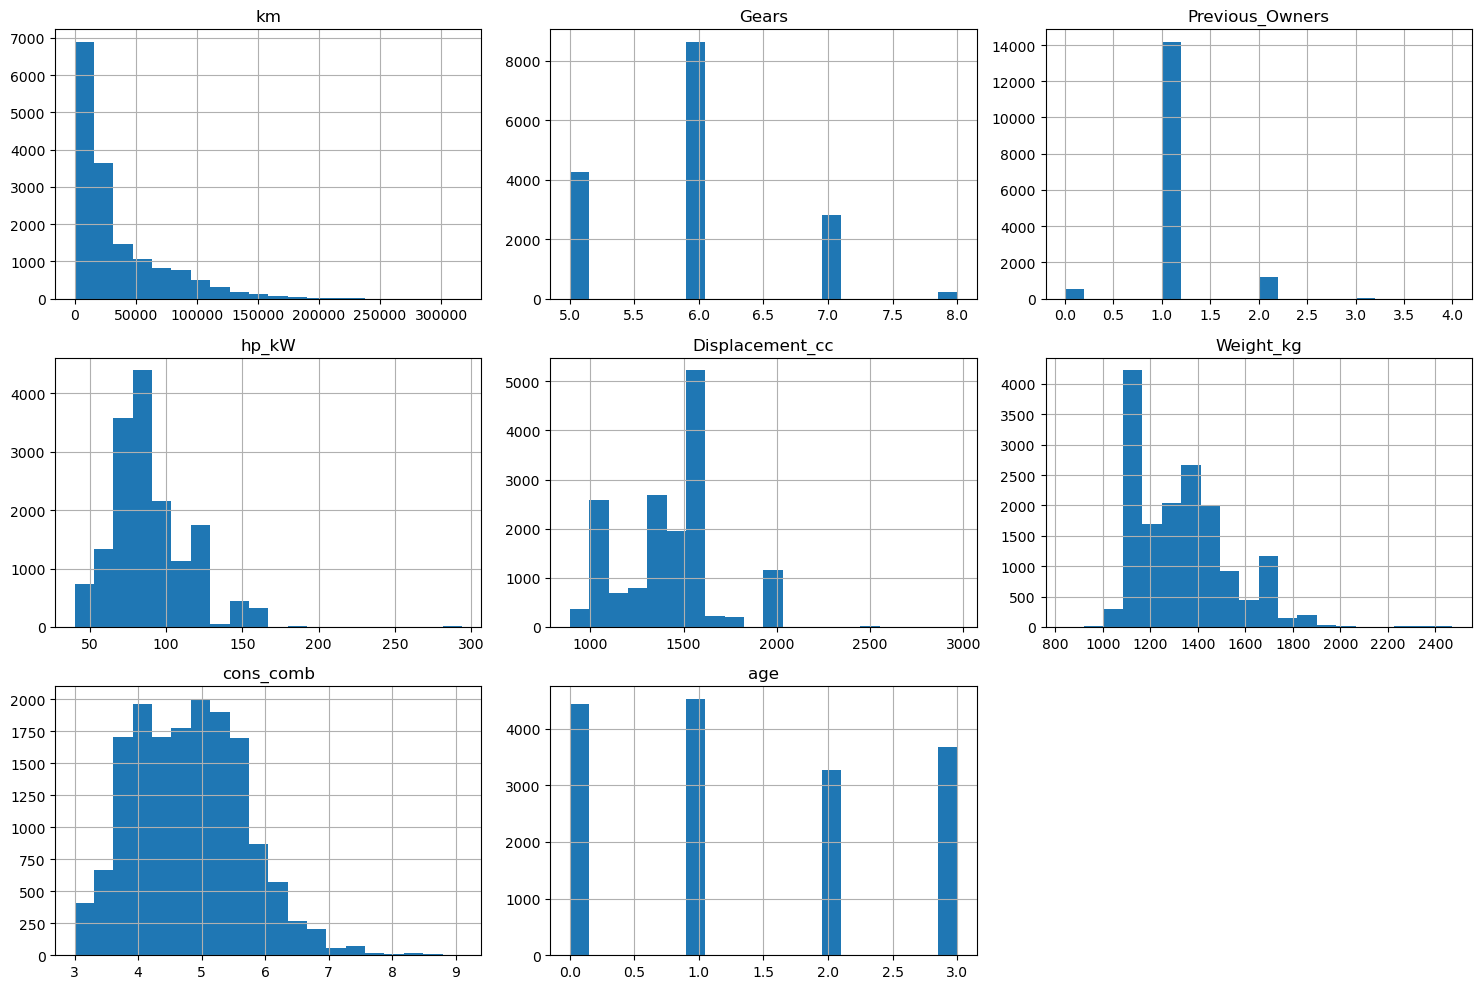

In [8]:

#Plot
df[numerical_features].hist(figsize=(15,10), bins=20)

plt.tight_layout()
plt.show()

#### **2.1.3** 
Identify categorical predictors and plot their frequency distributions.

In [9]:
# Identify categorical columns and check their frequency distributions
for col in categorical_features:
    print(f"\nFrequency Distribution of {col}:")
    print(df[col].value_counts())


Frequency Distribution of make_model:
make_model
Audi A3           3097
Audi A1           2614
Opel Insignia     2598
Opel Astra        2525
Opel Corsa        2216
Renault Clio      1839
Renault Espace     991
Renault Duster      34
Audi A2              1
Name: count, dtype: int64

Frequency Distribution of body_type:
body_type
Sedans           8004
Station wagon    3677
Compact          3240
Van               817
Transporter        88
Off-Road           56
Coupe              25
Convertible         8
Name: count, dtype: int64

Frequency Distribution of vat:
vat
VAT deductible      15044
Price negotiable      871
Name: count, dtype: int64

Frequency Distribution of Type:
Type
Used              11095
New                1649
Pre-registered     1364
Employee's car     1011
Demonstration       796
Name: count, dtype: int64

Frequency Distribution of Fuel:
Fuel
Benzine     8548
Diesel      7298
LPG/CNG       64
Electric       5
Name: count, dtype: int64

Frequency Distribution of Comfort_Co

**Note**: Look carefully at the values stored in columns `["Comfort_Convenience", "Entertainment_Media", "Extras", "Safety_Security"]`.

Should they be considered categorical? Should they be dropped or handled any other way?

In [10]:
from sklearn.preprocessing import MultiLabelBinarizer

multi_cat_cols = [
    'Comfort_Convenience',
    'Entertainment_Media',
    'Extras',
    'Safety_Security'
]

for col in multi_cat_cols:
    # 1. Split by comma AND strip whitespace from each individual item using a lambda function
    # This prevents duplicate columns like " Armrest" and "Armrest"
    df[col] = df[col].astype(str).str.split(',').apply(lambda x: [item.strip() for item in x])
    
    # 2. Initialize and Apply MultiLabelBinarizer
    mlb = MultiLabelBinarizer()
    transformed_data = mlb.fit_transform(df[col])
    
    # 3. Create the new dataframe with clean, non-duplicate feature names
    transformed_df = pd.DataFrame(
        transformed_data,
        columns=[f"{col}_{feature}" for feature in mlb.classes_],
        index=df.index
    )
    
    # 4. Merge with original dataframe
    df = pd.concat([df, transformed_df], axis=1)
    
    # 5. Drop original column
    df.drop(col, axis=1, inplace=True)

In [11]:
df.head()

,make_model,body_type,price,vat,km,Type,Fuel,Gears,age,Previous_Owners,hp_kW,Inspection_new,Paint_Type,Upholstery_type,Gearing_Type,Displacement_cc,Weight_kg,Drive_chain,cons_comb,Comfort_Convenience_Air conditioning,Comfort_Convenience_Air suspension,Comfort_Convenience_Armrest,Comfort_Convenience_Automatic climate control,Comfort_Convenience_Auxiliary heating,Comfort_Convenience_Cruise control,Comfort_Convenience_Electric Starter,Comfort_Convenience_Electric tailgate,Comfort_Convenience_Electrical side mirrors,Comfort_Convenience_Electrically adjustable seats,Comfort_Convenience_Electrically heated windshield,Comfort_Convenience_Heads-up display,Comfort_Convenience_Heated steering wheel,Comfort_Convenience_Hill Holder,Comfort_Convenience_Keyless central door lock,Comfort_Convenience_Leather seats,Comfort_Convenience_Leather steering wheel,Comfort_Convenience_Light sensor,Comfort_Convenience_Lumbar support,Comfort_Convenience_Massage seats,Comfort_Convenience_Multi-function steering wheel,Comfort_Convenience_Navigation system,Comfort_Convenience_Panorama roof,Comfort_Convenience_Park Distance Control,Comfort_Convenience_Parking assist system camera,Comfort_Convenience_Parking assist system self-steering,Comfort_Convenience_Parking assist system sensors front,Comfort_Convenience_Parking assist system sensors rear,Comfort_Convenience_Power windows,Comfort_Convenience_Rain sensor,Comfort_Convenience_Seat heating,Comfort_Convenience_Seat ventilation,Comfort_Convenience_Split rear seats,Comfort_Convenience_Start-stop system,Comfort_Convenience_Sunroof,Comfort_Convenience_Tinted windows,Comfort_Convenience_Wind deflector,Comfort_Convenience_Windshield,Entertainment_Media_Bluetooth,Entertainment_Media_CD player,Entertainment_Media_Digital radio,Entertainment_Media_Hands-free equipment,Entertainment_Media_MP3,Entertainment_Media_On-board computer,Entertainment_Media_Radio,Entertainment_Media_Sound system,Entertainment_Media_Television,Entertainment_Media_USB,Extras_Alloy wheels,Extras_Cab or rented Car,Extras_Catalytic Converter,Extras_Handicapped enabled,Extras_Right hand drive,Extras_Roof rack,Extras_Shift paddles,Extras_Ski bag,Extras_Sliding door,Extras_Sport package,Extras_Sport seats,Extras_Sport suspension,Extras_Touch screen,Extras_Trailer hitch,Extras_Tuned car,Extras_Voice Control,Extras_Winter tyres,Safety_Security_ABS,Safety_Security_Adaptive Cruise Control,Safety_Security_Adaptive headlights,Safety_Security_Alarm system,Safety_Security_Blind spot monitor,Safety_Security_Central door lock,Safety_Security_Central door lock with remote control,Safety_Security_Daytime running lights,Safety_Security_Driver drowsiness detection,Safety_Security_Driver-side airbag,Safety_Security_Electronic stability control,Safety_Security_Emergency brake assistant,Safety_Security_Emergency system,Safety_Security_Fog lights,Safety_Security_Head airbag,Safety_Security_Immobilizer,Safety_Security_Isofix,Safety_Security_LED Daytime Running Lights,Safety_Security_LED Headlights,Safety_Security_Lane departure warning system,Safety_Security_Night view assist,Safety_Security_Passenger-side airbag,Safety_Security_Power steering,Safety_Security_Rear airbag,Safety_Security_Side airbag,Safety_Security_Tire pressure monitoring system,Safety_Security_Traction control,Safety_Security_Traffic sign recognition,Safety_Security_Xenon headlights
0,Audi A1,Sedans,15770,VAT deductible,56013.0,Used,Diesel,7.0,3.0,2.0,66.0,1,Metallic,Cloth,Automatic,1422.0,1220.0,front,3.8,1,0,1,1,0,1,0,0,1,0,0,0,0,1,0,0,1,1,0,0,1,1,0,1,0,0,0,1,1,1,1,0,0,1,0,0,0,0,1,0,0,1,0,1,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,1,0,1,1,0,0,1,0,1,1,0,0,0,0,1,1,0,1,1,1,0,1
1,Audi A1,Sedans,14500,Price negotiable,80000.0,Used,Benzine,7.0,2.0,1.0,141.0,0,Metallic,Cloth,Automatic,1798.0,1255.0,front,5.6,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,1,0,1,0,0,1,0,0,1,0,1,1,1,0,0,1,0,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0,1,0,0,0,0,1,1,1,0,1,1,0,0,0,1,1,1,0,0,0,0,1,1,0,1,1,1,0

#### **2.1.4** 
Fix columns with low frequency values and class imbalances.

Some information regarding values in the `Type` column that may help:
- *'Pre-registered'* cars are ones which have already been registered previously by the seller.
- *'New'* cars are not necessarily new cars, but new-like cars. These might also have multiple owners due to multiple pre-registrations as well.
- *'Employee's car'* are cars used by employees over a short period of time and small distance.
- *'Demonstration'* cars are used for trial purposes and also driven for a short time and distance.

Based on these, you can handle this particular column. For other columns, decide a strategy on your own.

In [12]:
print("="*60)
print("       CLASS IMBALANCE & LOW FREQUENCY INSPECTION REPORT       ")
print("="*60)

# 3. Loop through columns to calculate exact frequency distributions
for col in categorical_features:
    if col in df.columns:
        print(f"\n🔹 Column: [{col}]")
        print("-" * 40)
        
        # Calculate counts and percentages
        counts = df[col].value_counts(dropna=False)
        percentages = df[col].value_counts(dropna=False, normalize=True) * 100
        
        # Combine into a clean summary table
        summary = pd.DataFrame({
            'Count': counts,
            'Percentage (%)': percentages.round(2)
        })
        print(summary)
        
        # Highlight potential problems (categories with < 1% representation)
        rare_classes = summary[summary['Percentage (%)'] < 1.0]
        if not rare_classes.empty:
            print(f"⚠️  WARNING: Potential rare classes found (< 1% of data):")
            for idx, row in rare_classes.iterrows():
                print(f"   - '{idx}': only {int(row['Count'])} rows ({row['Percentage (%)']}%)")
        print("-" * 40)

       CLASS IMBALANCE & LOW FREQUENCY INSPECTION REPORT       

🔹 Column: [make_model]
----------------------------------------
                Count  Percentage (%)
make_model                           
Audi A3          3097           19.46
Audi A1          2614           16.42
Opel Insignia    2598           16.32
Opel Astra       2525           15.87
Opel Corsa       2216           13.92
Renault Clio     1839           11.56
Renault Espace    991            6.23
Renault Duster     34            0.21
Audi A2             1            0.01
⚠️  WARNING: Potential rare classes found (< 1% of data):
   - 'Renault Duster': only 34 rows (0.21%)
   - 'Audi A2': only 1 rows (0.01%)
----------------------------------------

🔹 Column: [body_type]
----------------------------------------
               Count  Percentage (%)
body_type                           
Sedans          8004           50.29
Station wagon   3677           23.10
Compact         3240           20.36
Van              817     

In [13]:
# Fix columns as needed
# 1. Handle 'Type' column based on background information
# Reduce class imbalance in Type column

# Merge similar categories into broader groups
type_map = {
    'Used': 'Used',
    'New': 'New_or_PreRegistered',
    'Pre-registered': 'New_or_PreRegistered',
    "Employee's car": 'New_or_PreRegistered',
    'Demonstration': 'New_or_PreRegistered'
}
df['Type'] = df['Type'].map(type_map)

# 2. Handle 'make_model' rare classes
df['make_model'] = df['make_model'].replace({'Renault Duster': 'Other_Model', 'Audi A2': 'Other_Model'})

# 3. Handle 'body_type' fragmentation
body_map = {
    'Sedans': 'Sedans',
    'Station wagon': 'Station wagon',
    'Compact': 'Compact',
    'Van': 'Van/Transporter',
    'Transporter': 'Van/Transporter',
    'Off-Road': 'Niche_Style',
    'Coupe': 'Niche_Style',
    'Convertible': 'Niche_Style'
}
df['body_type'] = df['body_type'].map(body_map)

# 4. Handle 'Fuel' minority classes
df['Fuel'] = df['Fuel'].replace({'LPG/CNG': 'Other_Fuel', 'Electric': 'Other_Fuel'})

# 5. Handle 'Paint_Type' rare Perl effect
df['Paint_Type'] = df['Paint_Type'].replace({'Perl effect': 'Non-Metallic', 'Uni/basic': 'Non-Metallic'})

# 6. Handle 'Drive_chain' extreme rear-wheel minority
df['Drive_chain'] = df['Drive_chain'].replace({'rear': '4WD_or_Rear', '4WD': '4WD_or_Rear'})

# =====================================================================
# VERIFICATION PIPELINE
# =====================================================================
print("="*60)
print("      VERIFICATION REPORT AFTER BALANCING STRATEGIES       ")
print("="*60)

cols_to_verify = ['make_model', 'body_type', 'Type', 'Fuel', 'Paint_Type', 'Drive_chain']
for col in cols_to_verify:
    print(f"\n✅ Cleaned Column: [{col}]")
    print("-" * 40)
    counts = df[col].value_counts()
    percentages = df[col].value_counts(normalize=True) * 100
    summary = pd.DataFrame({'Count': counts, 'Percentage (%)': percentages.round(2)})
    print(summary)
    print("-" * 40)

      VERIFICATION REPORT AFTER BALANCING STRATEGIES       

✅ Cleaned Column: [make_model]
----------------------------------------
                Count  Percentage (%)
make_model                           
Audi A3          3097           19.46
Audi A1          2614           16.42
Opel Insignia    2598           16.32
Opel Astra       2525           15.87
Opel Corsa       2216           13.92
Renault Clio     1839           11.56
Renault Espace    991            6.23
Other_Model        35            0.22
----------------------------------------

✅ Cleaned Column: [body_type]
----------------------------------------
                 Count  Percentage (%)
body_type                             
Sedans            8004           50.29
Station wagon     3677           23.10
Compact           3240           20.36
Van/Transporter    905            5.69
Niche_Style         89            0.56
----------------------------------------

✅ Cleaned Column: [Type]
----------------------------------

#### **2.1.5** 
Identify target variable and plot the frequency distributions. Apply necessary transformations.

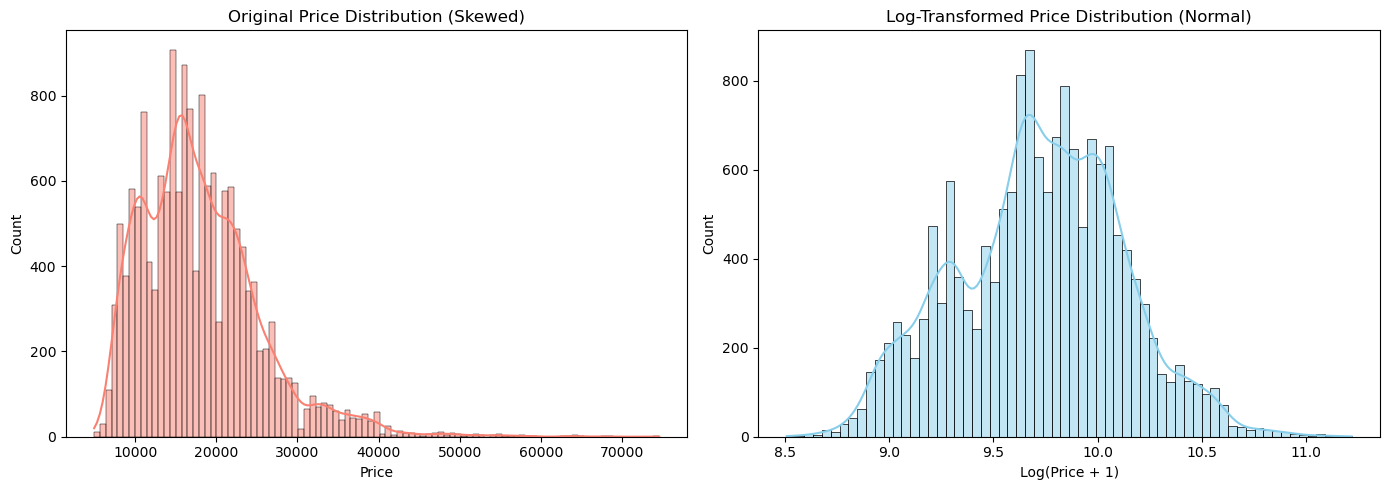

Target transformed and rare categories handled successfully!


In [16]:
import seaborn as sns
import numpy as np
# Handle rare categories based on frequency distributions
# =====================================================================
# STEP 1: TARGET VARIABLE ANALYSIS & TRANSFORMATION
# =====================================================================
target = 'price'

# Set up a side-by-side plot to see Before vs After transformation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Original Price Distribution (Highly Skewed)
sns.histplot(df[target], kde=True, ax=axes[0], color='salmon')
axes[0].set_title('Original Price Distribution (Skewed)', fontsize=12)
axes[0].set_xlabel('Price')

# Apply Log Transformation to make it normally distributed
df['price_log'] = np.log1p(df[target])

# Plot 2: Log-Transformed Price Distribution (Bell Curve / Normal)
sns.histplot(df['price_log'], kde=True, ax=axes[1], color='skyblue')
axes[1].set_title('Log-Transformed Price Distribution (Normal)', fontsize=12)
axes[1].set_xlabel('Log(Price + 1)')

plt.tight_layout()
plt.show()

# =====================================================================
# STEP 2: HANDLE RARE CATEGORIES BASED ON FREQUENCY DISTRIBUTIONS
# =====================================================================

# 1. Handle 'Type' column based on background information
type_map = {
    'Used': 'Used',
    'New': 'New_or_PreRegistered',
    'Pre-registered': 'New_or_PreRegistered',
    "Employee's car": 'New_or_PreRegistered',
    'Demonstration': 'New_or_PreRegistered'
}
df['Type'] = df['Type'].map(type_map)

# 2. Handle 'make_model' rare classes
df['make_model'] = df['make_model'].replace({'Renault Duster': 'Other_Model', 'Audi A2': 'Other_Model'})

# 3. Handle 'body_type' fragmentation
body_map = {
    'Sedans': 'Sedans',
    'Station wagon': 'Station wagon',
    'Compact': 'Compact',
    'Van': 'Van/Transporter',
    'Transporter': 'Van/Transporter',
    'Off-Road': 'Niche_Style',
    'Coupe': 'Niche_Style',
    'Convertible': 'Niche_Style'
}
df['body_type'] = df['body_type'].map(body_map)

# 4. Handle 'Fuel' minority classes
df['Fuel'] = df['Fuel'].replace({'LPG/CNG': 'Other_Fuel', 'Electric': 'Other_Fuel'})

# 5. Handle 'Paint_Type' rare Perl effect
df['Paint_Type'] = df['Paint_Type'].replace({'Perl effect': 'Non-Metallic', 'Uni/basic': 'Non-Metallic'})

# 6. Handle 'Drive_chain' extreme rear-wheel minority
df['Drive_chain'] = df['Drive_chain'].replace({'rear': '4WD_or_Rear', '4WD': '4WD_or_Rear'})

print("Target transformed and rare categories handled successfully!")

In [17]:
# Final adjustments for low-frequency categories

# 1. Identify all the binary columns created by MultiLabelBinarizer
# (They all start with our prefix names)
bin_prefixes = ('Comfort_Convenience_', 'Entertainment_Media_', 'Extras_', 'Safety_Security_')
mlb_columns = [col for col in df.columns if col.startswith(bin_prefixes)]

# 2. Set a threshold (e.g., column must be '1' in at least 1% of the dataset)
threshold = 0.01 * len(df)  # 1% of 15,915 is roughly 159 cars

columns_to_drop = []

# 3. Find which columns fall below the threshold
for col in mlb_columns:
    # Count how many times this feature is present (equal to 1)
    feature_count = df[col].sum() 
    if feature_count < threshold:
        columns_to_drop.append(col)

print(f"Scanning complete. Found {len(columns_to_drop)} rare features to drop.")
print("Examples of features being dropped due to low frequency:")
print(columns_to_drop[:10])  # Show a preview of what's being removed

# 4. Drop the low-frequency feature columns
df.drop(columns=columns_to_drop, inplace=True)

print(f"\nFinal adjustments complete! Remaining columns in dataframe: {df.shape[1]}")

Scanning complete. Found 11 rare features to drop.
Examples of features being dropped due to low frequency:
['Comfort_Convenience_Air suspension', 'Comfort_Convenience_Electric Starter', 'Comfort_Convenience_Leather seats', 'Comfort_Convenience_Wind deflector', 'Comfort_Convenience_Windshield', 'Entertainment_Media_Television', 'Extras_Handicapped enabled', 'Extras_Right hand drive', 'Extras_Sliding door', 'Extras_Tuned car']

Final adjustments complete! Remaining columns in dataframe: 103


In [18]:
# Verify updated frequency distributions

# =====================================================================
# VERIFY UPDATED FREQUENCY DISTRIBUTIONS FOR BINARY FEATURES
# =====================================================================

# 1. Identify the binary features that remain after the filter
bin_prefixes = ('Comfort_Convenience_', 'Entertainment_Media_', 'Extras_', 'Safety_Security_')
remaining_mlb_columns = [col for col in df.columns if col.startswith(bin_prefixes)]

print("=" * 60)
print(f"    VERIFICATION REPORT: REMAINING MULTI-LABEL FEATURES ({len(remaining_mlb_columns)} Total)")
print("=" * 60)

# 2. Create a summary DataFrame for all remaining binary features
summary_data = []
for col in remaining_mlb_columns:
    total_count = df[col].sum()
    percentage = (total_count / len(df)) * 100
    summary_data.append({
        'Feature Name': col,
        'Count (Active)': total_count,
        'Percentage (%)': round(percentage, 2)
    })

# Convert to DataFrame and sort by most frequent to least frequent
verification_df = pd.DataFrame(summary_data).sort_values(by='Count (Active)', ascending=False)

# Display the entire verification list
pd.set_option('display.max_rows', None)  # Show all lines
print(verification_df.to_string(index=False))

    VERIFICATION REPORT: REMAINING MULTI-LABEL FEATURES (83 Total)
                                           Feature Name  Count (Active)  Percentage (%)
                   Comfort_Convenience_Air conditioning           15095           94.85
                                    Safety_Security_ABS           15022           94.39
                     Safety_Security_Driver-side airbag           14801           93.00
                      Comfort_Convenience_Power windows           14756           92.72
                         Safety_Security_Power steering           14489           91.04
                  Safety_Security_Passenger-side airbag           14333           90.06
           Safety_Security_Electronic stability control           14077           88.45
                            Safety_Security_Side airbag           13998           87.95
                                    Extras_Alloy wheels           13994           87.93
                      Safety_Security_Central door lo

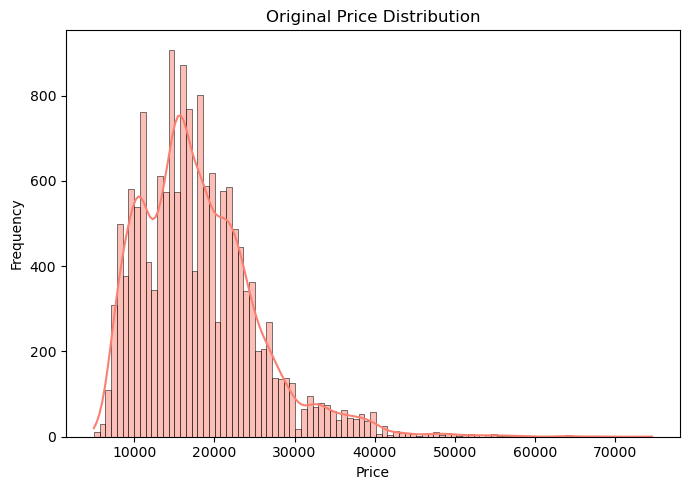

In [20]:
# Plot histograms for target feature
# Identify target feature
fig, ax = plt.subplots(figsize=(7, 5))
sns.histplot(df['price'], kde=True, color='salmon')
ax.set_title('Original Price Distribution')
ax.set_xlabel('Price')
ax.set_ylabel('Frequency')

plt.tight_layout()

**The target variable seems to be skewed. Perform suitable transformation on the target.**

In [22]:
# Transform the target feature
# Transform the target feature using log transformation

df['price_log'] = np.log1p(df['price'])




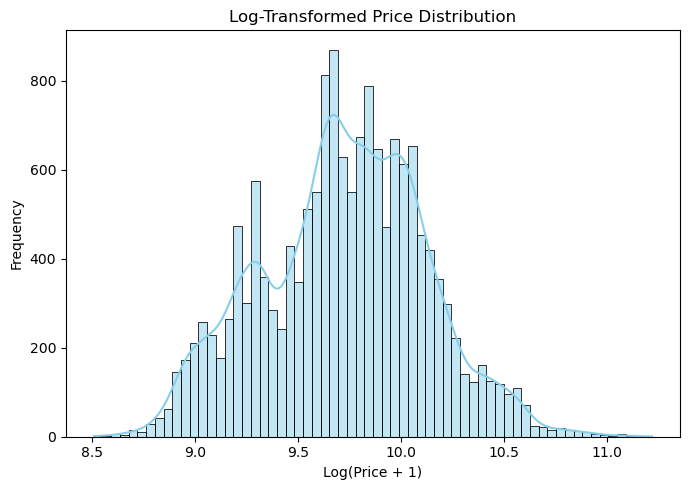

In [23]:
# Plot transformed target distribution

fig, ax = plt.subplots(figsize=(7, 5))
sns.histplot(df['price_log'], kde=True, color='skyblue')
ax.set_title('Log-Transformed Price Distribution')
ax.set_xlabel('Log(Price + 1)')
ax.set_ylabel('Frequency')

plt.tight_layout()

### **2.2 Correlation analysis** <font color = red>  </font>

#### **2.2.1** 
Plot the correlation map between features and target variable.

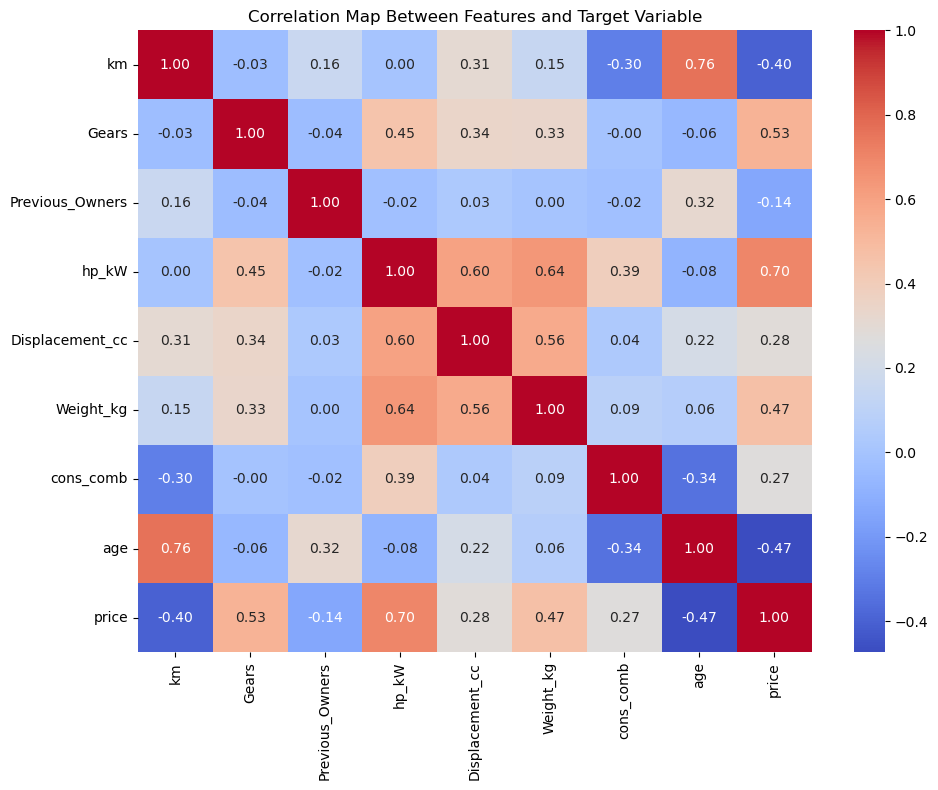

In [24]:
# Visualise correlation
# Correlation matrix for numerical features
# List of numerical features and the target variable
numerical_cols = ['km', 'Gears', 'Previous_Owners', 'hp_kW', 'Displacement_cc', 'Weight_kg', 'cons_comb', 'age', 'price']

# Visualise correlation
# Correlation matrix for numerical features
correlation_matrix = df[numerical_cols].corr()

# Plot the correlation map between features and target variable
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", ax=ax)
ax.set_title('Correlation Map Between Features and Target Variable')

plt.tight_layout()


In [25]:
# Select only actual numerical features + engineered binary features

numerical_features = ['km', 'Gears', 'Previous_Owners', 'hp_kW', 'Displacement_cc', 'Weight_kg', 'cons_comb', 'age']
target_features = ['price', 'price_log']

# Identify engineered binary features (from MultiLabelBinarizer)
bin_prefixes = ('Comfort_Convenience_', 'Entertainment_Media_', 'Extras_', 'Safety_Security_')
engineered_binary_features = [col for col in df.columns if col.startswith(bin_prefixes)]

# Include other structural binary variables like Inspection_new
other_binary_features = ['Inspection_new'] if 'Inspection_new' in df.columns else []

# Select only actual numerical features + engineered binary features
selected_cols = numerical_features + target_features + engineered_binary_features + other_binary_features
df_filtered = df[selected_cols]

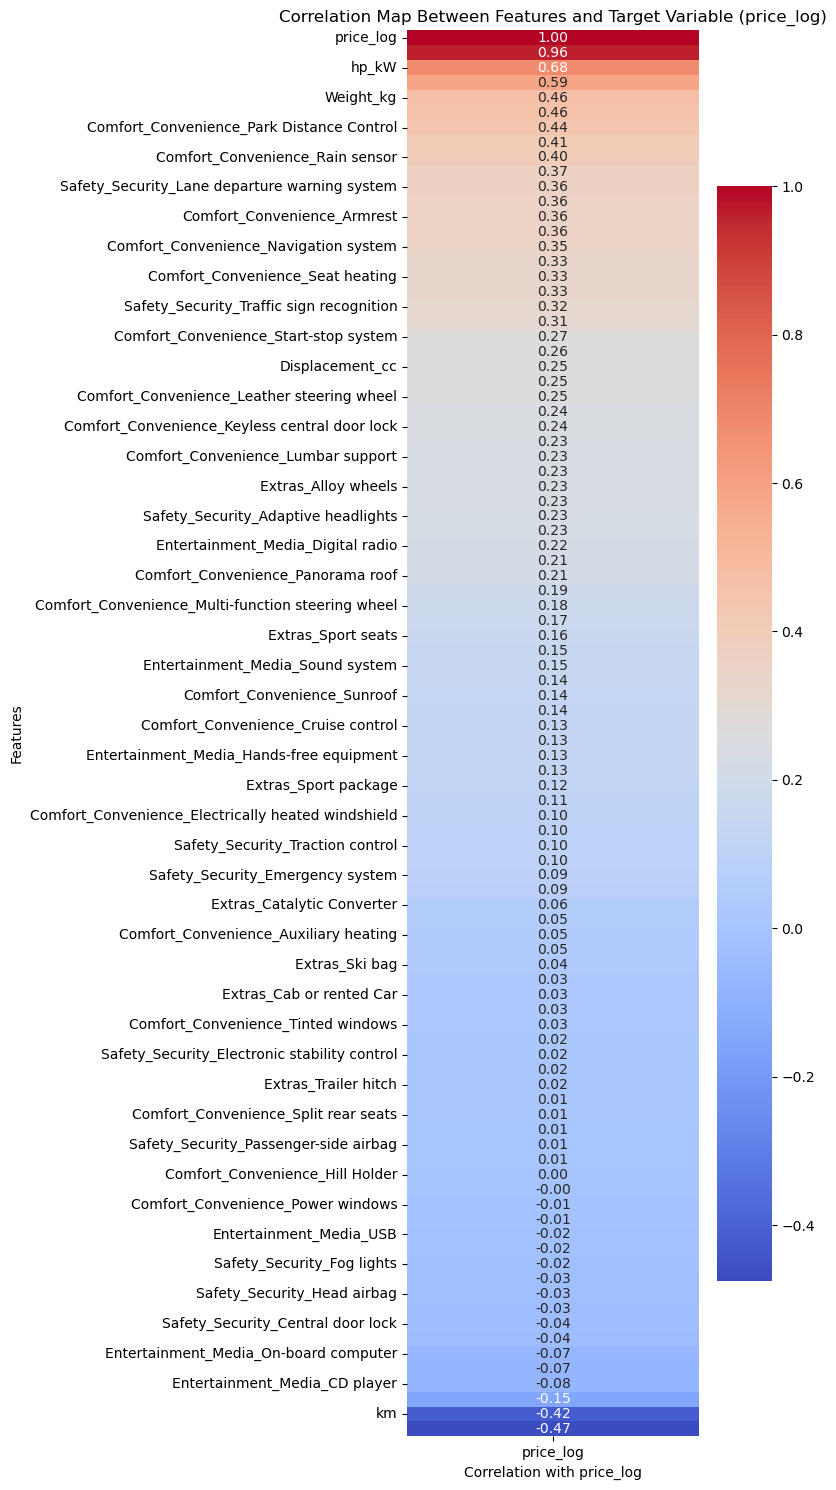

In [26]:
# Calculate the correlation matrix for the selected features and target
correlation_matrix = df_filtered.corr()

# Extract correlation values specifically with the target feature (price_log)
# and sort them from highest to lowest correlation
target_correlation = correlation_matrix[['price_log']].sort_values(by='price_log', ascending=False)

# Plot the correlation map between features and target variable
fig, ax = plt.subplots(figsize=(8, 15))
sns.heatmap(target_correlation, annot=True, cmap='coolwarm', fmt=".2f", ax=ax, cbar=True)
ax.set_title('Correlation Map Between Features and Target Variable (price_log)', fontsize=12)
ax.set_ylabel('Features')
ax.set_xlabel('Correlation with price_log')

plt.tight_layout()

#### **2.2.2** 
Analyse correlation between categorical features and target variable.

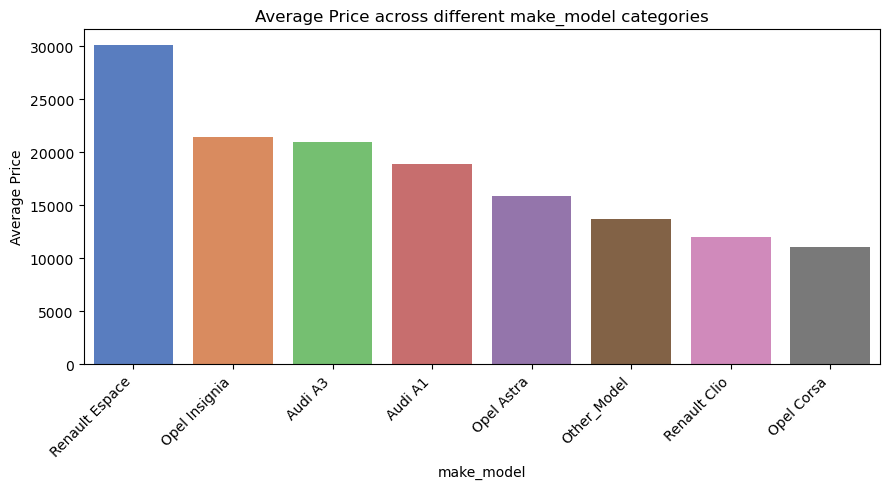

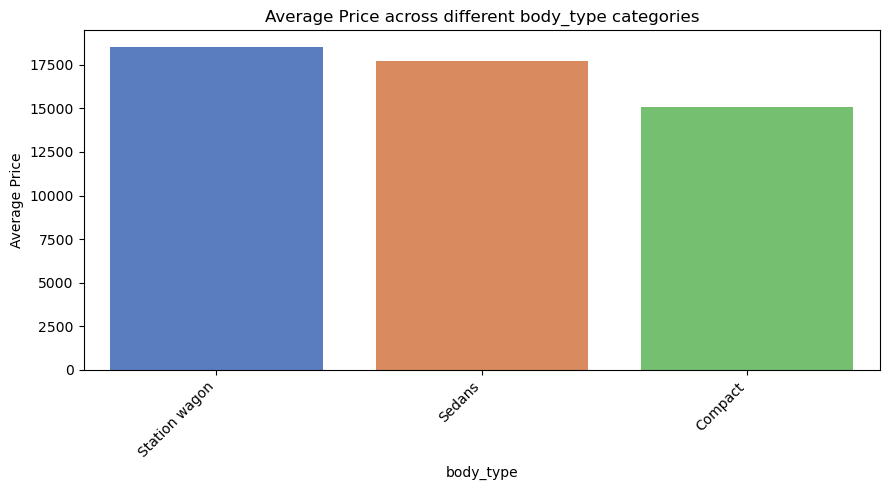

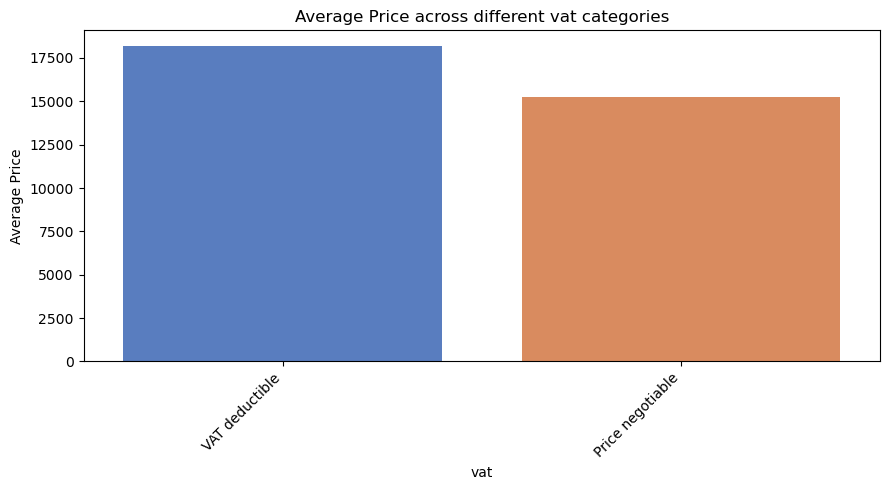

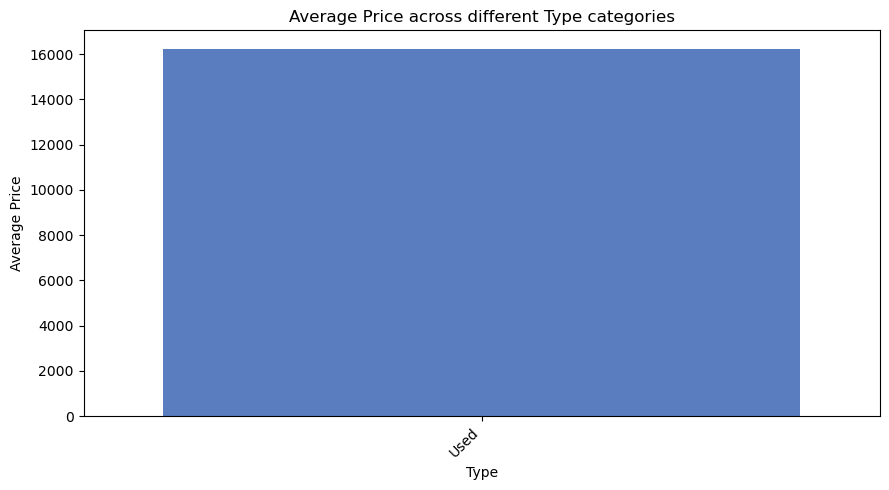

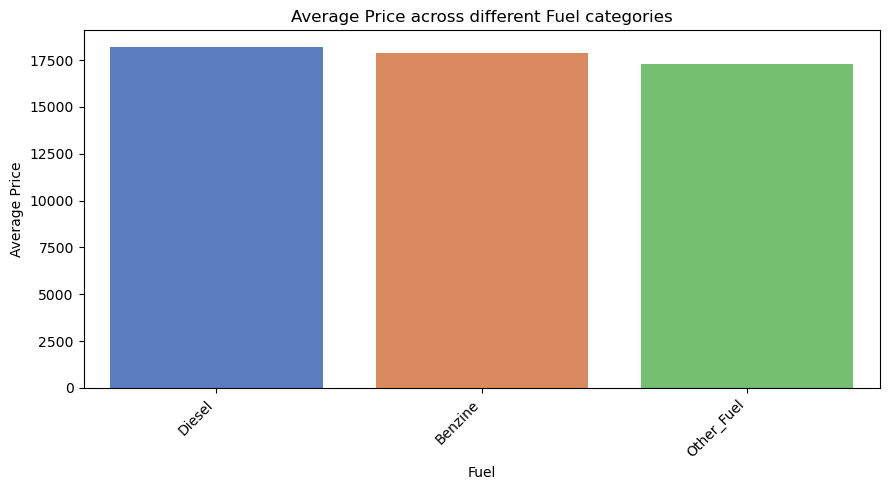

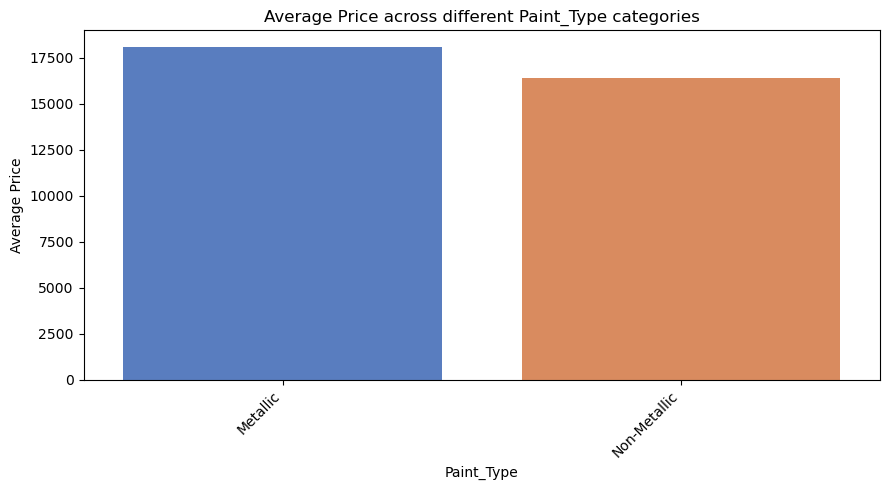

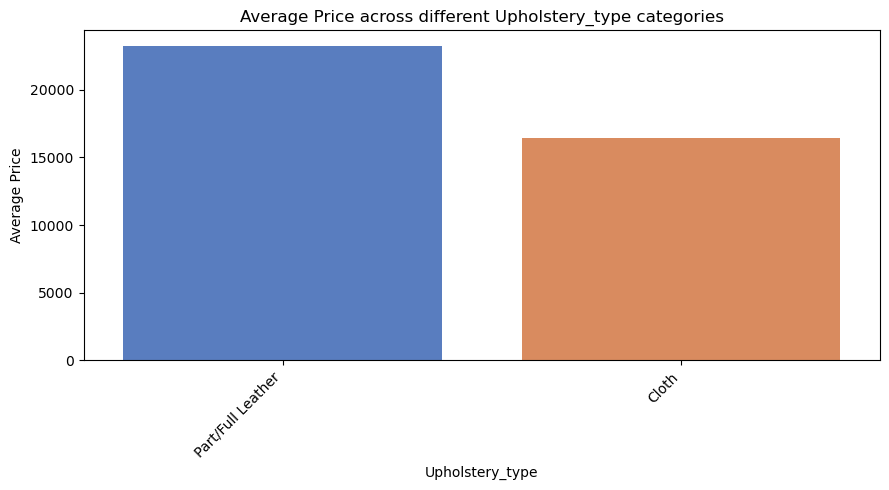

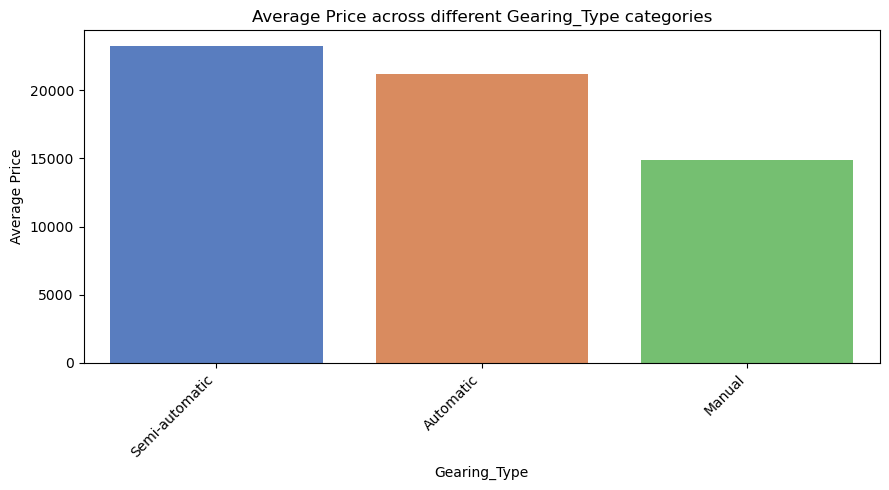

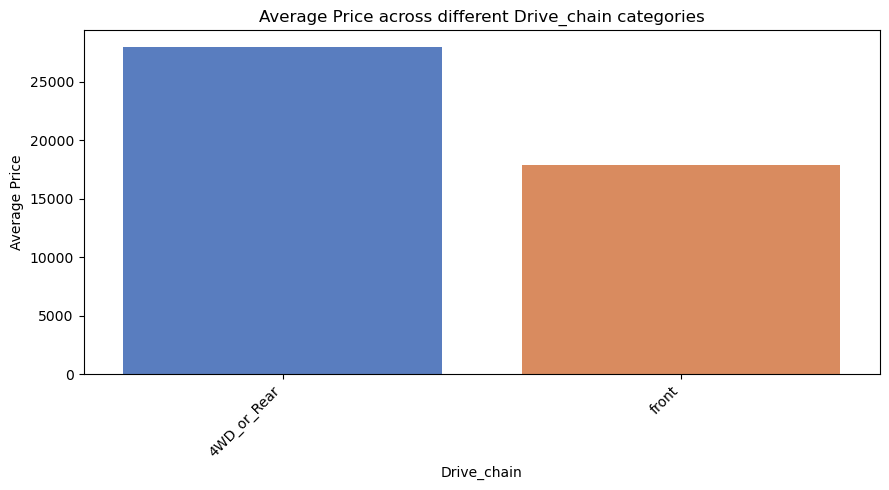

In [29]:
# Comparing average values of target for different categories
# Compare average target values across categorical features
# List of categorical features to analyze
categorical_features = ['make_model', 'body_type', 'vat', 'Type', 'Fuel', 'Paint_Type', 'Upholstery_type', 'Gearing_Type', 'Drive_chain']

# Comparing average values of target for different categories
# Compare average target values across categorical features
for col in categorical_features:
    if col in df.columns:
        # Calculate the mean target values for each category group
        category_means = df.groupby(col)['price'].mean().sort_values(ascending=False).reset_index()
        
        # Plotting the average values (fixing the palette deprecation warnings)
        fig, ax = plt.subplots(figsize=(9, 5))
        sns.barplot(x=col, y='price', data=category_means, ax=ax, hue=col, palette='muted', legend=False)
        ax.set_title(f'Average Price across different {col} categories')
        ax.set_xlabel(col)
        ax.set_ylabel('Average Price')
        
        # Format labels to prevent overlapping
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        


### **2.3 Outlier analysis** <font color = red>  </font>

#### **2.3.1** 
Identify potential outliers in the data.

In [30]:
# Outliers present in each column
# List of numerical columns to inspect for outliers
numerical_cols = ['km', 'Gears', 'Previous_Owners', 'hp_kW', 'Displacement_cc', 'Weight_kg', 'cons_comb', 'age', 'price']

print("="*60)
print("               OUTLIER ANALYSIS REPORT (IQR METHOD)            ")
print("="*60)

outlier_summary = {}

# Identify potential outliers in the data
# Outliers present in each column
for col in numerical_cols:
    if col in df.columns:
        # Calculate Q1 (25th percentile) and Q3 (75th percentile)
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        
        # Calculate Interquartile Range (IQR)
        IQR = Q3 - Q1
        
        # Define bounds for outliers
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Identify outliers
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_count = len(outliers)
        outlier_percentage = (outlier_count / len(df)) * 100
        
        outlier_summary[col] = {
            'Q1': Q1,
            'Q3': Q3,
            'IQR': IQR,
            'Lower Bound': round(lower_bound, 2),
            'Upper Bound': round(upper_bound, 2),
            'Outlier Count': outlier_count,
            'Percentage (%)': round(outlier_percentage, 2)
        }
        
        print(f"\n🔹 Column: [{col}]")
        print(f"   - Q1 (25th percentile): {Q1}")
        print(f"   - Q3 (75th percentile): {Q3}")
        print(f"   - IQR: {IQR}")
        print(f"   - Outlier Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
        print(f"   - Number of Outliers: {outlier_count} ({outlier_percentage:.2f}%)")

print("\n" + "="*60)
print("                     SUMMARY OF OUTLIERS                       ")
print("="*60)
summary_df = pd.DataFrame(outlier_summary).T[['Outlier Count', 'Percentage (%)']]
print(summary_df)


               OUTLIER ANALYSIS REPORT (IQR METHOD)            

🔹 Column: [km]
   - Q1 (25th percentile): 1920.5
   - Q3 (75th percentile): 46900.0
   - IQR: 44979.5
   - Outlier Bounds: [-65548.75, 114369.25]
   - Number of Outliers: 689 (4.33%)

🔹 Column: [Gears]
   - Q1 (25th percentile): 5.0
   - Q3 (75th percentile): 6.0
   - IQR: 1.0
   - Outlier Bounds: [3.50, 7.50]
   - Number of Outliers: 225 (1.41%)

🔹 Column: [Previous_Owners]
   - Q1 (25th percentile): 1.0
   - Q3 (75th percentile): 1.0
   - IQR: 0.0
   - Outlier Bounds: [1.00, 1.00]
   - Number of Outliers: 1757 (11.04%)

🔹 Column: [hp_kW]
   - Q1 (25th percentile): 66.0
   - Q3 (75th percentile): 103.0
   - IQR: 37.0
   - Outlier Bounds: [10.50, 158.50]
   - Number of Outliers: 361 (2.27%)

🔹 Column: [Displacement_cc]
   - Q1 (25th percentile): 1229.0
   - Q3 (75th percentile): 1598.0
   - IQR: 369.0
   - Outlier Bounds: [675.50, 2151.50]
   - Number of Outliers: 21 (0.13%)

🔹 Column: [Weight_kg]
   - Q1 (25th percentile

In [31]:
# Check the unique values and their distributions
print(df['Previous_Owners'].value_counts(dropna=False))

Previous_Owners
1.0    14158
2.0     1172
0.0      554
3.0       29
4.0        2
Name: count, dtype: int64


#### **2.3.2** 
Handle the outliers suitably.

In [32]:
# Handle outliers
# Detect outliers using IQR method
# List of numerical features to handle outliers for (excluding target features)
numerical_cols = ['km', 'Gears', 'Previous_Owners', 'hp_kW', 'Displacement_cc', 'Weight_kg', 'cons_comb', 'age']

# Handle outliers using IQR Capping (Winsorization)
for col in numerical_cols:
    if col in df.columns:
        # Calculate Q1, Q3, and IQR
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        # Define the exact bounds from your analysis
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Cap values below the lower bound and above the upper bound
        df[col] = np.clip(df[col], lower_bound, upper_bound)

print("Outliers have been successfully handled by capping extreme values to their IQR bounds.")

Outliers have been successfully handled by capping extreme values to their IQR bounds.


In [33]:
print("="*60)
print("          VERIFICATION REPORT: POST-OUTLIER HANDLING           ")
print("="*60)

# Verify that all values are now contained within the IQR bounds
for col in numerical_cols:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Check if any values remain outside bounds
        remaining_outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        
        print(f"🔹 Column: [{col}]")
        print(f"   - Minimum value: {df[col].min()}")
        print(f"   - Maximum value: {df[col].max()}")
        print(f"   - Remaining Outliers: {len(remaining_outliers)}")

          VERIFICATION REPORT: POST-OUTLIER HANDLING           
🔹 Column: [km]
   - Minimum value: 0.0
   - Maximum value: 114369.25
   - Remaining Outliers: 0
🔹 Column: [Gears]
   - Minimum value: 5.0
   - Maximum value: 7.5
   - Remaining Outliers: 0
🔹 Column: [Previous_Owners]
   - Minimum value: 1.0
   - Maximum value: 1.0
   - Remaining Outliers: 0
🔹 Column: [hp_kW]
   - Minimum value: 40.0
   - Maximum value: 158.5
   - Remaining Outliers: 0
🔹 Column: [Displacement_cc]
   - Minimum value: 890.0
   - Maximum value: 2151.5
   - Remaining Outliers: 0
🔹 Column: [Weight_kg]
   - Minimum value: 840.0
   - Maximum value: 1932.5
   - Remaining Outliers: 0
🔹 Column: [cons_comb]
   - Minimum value: 3.0
   - Maximum value: 7.350000000000001
   - Remaining Outliers: 0
🔹 Column: [age]
   - Minimum value: 0.0
   - Maximum value: 3.0
   - Remaining Outliers: 0


### **2.4 Feature Engineering** <font color = red>  </font>

#### **2.4.1**
Fix any redundant columns and create new ones if needed.

In [35]:
# Fix/create columns as needed
# Drop redundant original multi-label columns

# Drop the zero-variance column resulting from outlier capping
if 'Previous_Owners' in df.columns:
    df.drop(columns=['Previous_Owners'], inplace=True)
    print("Dropped 'Previous_Owners' due to zero variance after outlier capping.")

print("="*60)
print("               DATASET INSPECTION FOR REDUNDANCY               ")
print("="*60)

# 1. Inspect Variance (Find Zero or Near-Zero Variance columns)
print("\n1. Checking for Low/Zero Variance Columns:")
for col in df.columns:
    # Get the proportion of the most frequent value
    most_freq_share = df[col].value_counts(normalize=True).iloc[0]
    unique_counts = df[col].nunique()
    
    if unique_counts == 1:
        print(f"   ⚠️ [REDUNDANT - DROP] '{col}' has zero variance (100% of rows have the exact same value).")
    elif most_freq_share > 0.98:
        print(f"   ⚠️ [NEAR-ZERO VARIANCE] '{col}' is highly skewed ({most_freq_share*100:.2f}% rows have the same value).")

# 2. Inspect Correlation Matrix for Numerical Duplication (Multicolliniarity)
print("\n2. Checking High Correlation among Numerical Features:")
numerical_df = df.select_dtypes(include=[np.number])
if not numerical_df.empty:
    corr_matrix = numerical_df.corr().abs()
    # Upper triangle of correlation matrix to avoid duplication
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Find columns with correlation greater than 0.95
    high_corr_cols = [column for column in upper.columns if any(upper[column] > 0.95)]
    for col in high_corr_cols:
        correlated_with = upper.index[upper[col] > 0.95].tolist()
        print(f"   ⚠️ [HIGH CORRELATION] '{col}' is highly correlated (>0.95) with {correlated_with}. One might be redundant.")

# 3. Inspect Categorical Features (To find potential text grouping/simplification opportunities)
print("\n3. Checking Categorical Cardinality & Sample Values:")
categorical_df = df.select_dtypes(include=['object', 'category'])
for col in categorical_df.columns:
    n_unique = df[col].nunique()
    sample_vals = df[col].dropna().unique()[:3]
    print(f"   🔹 '{col}': {n_unique} unique categories. Examples: {sample_vals}")
    if n_unique > 20:
        print(f"      👉 (Hint: Consider grouping rare categories or extracting sub-features to avoid high cardinality.)")

print("\n" + "="*60)

               DATASET INSPECTION FOR REDUNDANCY               

1. Checking for Low/Zero Variance Columns:
   ⚠️ [REDUNDANT - DROP] 'Type' has zero variance (100% of rows have the exact same value).
   ⚠️ [NEAR-ZERO VARIANCE] 'Drive_chain' is highly skewed (98.69% rows have the same value).
   ⚠️ [NEAR-ZERO VARIANCE] 'Comfort_Convenience_Auxiliary heating' is highly skewed (98.33% rows have the same value).
   ⚠️ [NEAR-ZERO VARIANCE] 'Extras_Cab or rented Car' is highly skewed (98.05% rows have the same value).
   ⚠️ [NEAR-ZERO VARIANCE] 'Extras_Ski bag' is highly skewed (98.42% rows have the same value).
   ⚠️ [NEAR-ZERO VARIANCE] 'Extras_Winter tyres' is highly skewed (98.45% rows have the same value).

2. Checking High Correlation among Numerical Features:
   ⚠️ [HIGH CORRELATION] 'price_log' is highly correlated (>0.95) with ['price']. One might be redundant.

3. Checking Categorical Cardinality & Sample Values:
   🔹 'make_model': 8 unique categories. Examples: ['Audi A1' 'Other_M

In [36]:
# 1. Drop the absolute zero-variance column
cols_to_drop = ['Type']

# 2. Drop the near-zero variance binary features (>98% skewness)
near_zero_variance_cols = [
    'Comfort_Convenience_Auxiliary heating',
    'Extras_Cab or rented Car',
    'Extras_Ski bag',
    'Extras_Winter tyres'
]
cols_to_drop.extend(near_zero_variance_cols)

# 3. Drop the original price column to avoid target redundancy/leakage
# (We keep 'price_log' as our primary target variable)
if 'price' in df.columns and 'price_log' in df.columns:
    cols_to_drop.append('price')

# Execute the dropping of redundant columns
df.drop(columns=[col for col in cols_to_drop if col in df.columns], inplace=True)
print(f"Dropped redundant/low-variance columns: {cols_to_drop}")


# 4. Create a new engineered feature: Kilometers driven per year
# We add +1 to age to avoid any division-by-zero errors for brand new cars (age = 0)
if 'km' in df.columns and 'age' in df.columns:
    df['km_per_year'] = df['km'] / (df['age'] + 1)
    print("Created new engineered feature: 'km_per_year'")

# Verify the final list of columns
print(f"\nUpdated dataset shape: {df.shape}")

Dropped redundant/low-variance columns: ['Type', 'Comfort_Convenience_Auxiliary heating', 'Extras_Cab or rented Car', 'Extras_Ski bag', 'Extras_Winter tyres', 'price']
Created new engineered feature: 'km_per_year'

Updated dataset shape: (15915, 97)


#### **2.4.2** 
Analysis and feature engineering on `['Comfort_Convenience', 'Entertainment_Media', 'Extras', 'Safety_Security']`.

These columns contains lists of features present. Decide on how to include these features in the predictors.

In [38]:
# Check unique values in each feature spec column
# Analyse engineered binary feature columns
matched_cols = [col for col in df.columns if any(x in col for x in ['Comfort_Convenience', 'Entertainment_Media', 'Extras', 'Safety_Security'])]

print(f"Total matched sub-features found: {len(matched_cols)}")
print("\nA sample of these columns looks like this:")
print(matched_cols[:15])  # Show the first 15 columns

Total matched sub-features found: 79

A sample of these columns looks like this:
['Comfort_Convenience_Air conditioning', 'Comfort_Convenience_Armrest', 'Comfort_Convenience_Automatic climate control', 'Comfort_Convenience_Cruise control', 'Comfort_Convenience_Electric tailgate', 'Comfort_Convenience_Electrical side mirrors', 'Comfort_Convenience_Electrically adjustable seats', 'Comfort_Convenience_Electrically heated windshield', 'Comfort_Convenience_Heads-up display', 'Comfort_Convenience_Heated steering wheel', 'Comfort_Convenience_Hill Holder', 'Comfort_Convenience_Keyless central door lock', 'Comfort_Convenience_Leather steering wheel', 'Comfort_Convenience_Light sensor', 'Comfort_Convenience_Lumbar support']


          ANALYSIS: BINARY FEATURES VS TARGET          

🔥 Top 10 premium features most positively correlated with higher price:
Comfort_Convenience_Automatic climate control              0.461479
Comfort_Convenience_Park Distance Control                  0.439057
Safety_Security_LED Headlights                             0.411695
Comfort_Convenience_Rain sensor                            0.403188
Comfort_Convenience_Parking assist system sensors rear     0.371421
Safety_Security_Lane departure warning system              0.364849
Comfort_Convenience_Parking assist system sensors front    0.358592
Comfort_Convenience_Armrest                                0.356259
Comfort_Convenience_Light sensor                           0.356230
Comfort_Convenience_Navigation system                      0.352029
dtype: float64

📉 Top 5 basic features (often associated with cheaper or standard models):
Safety_Security_Central door lock                       -0.035092
Safety_Security_ABS               

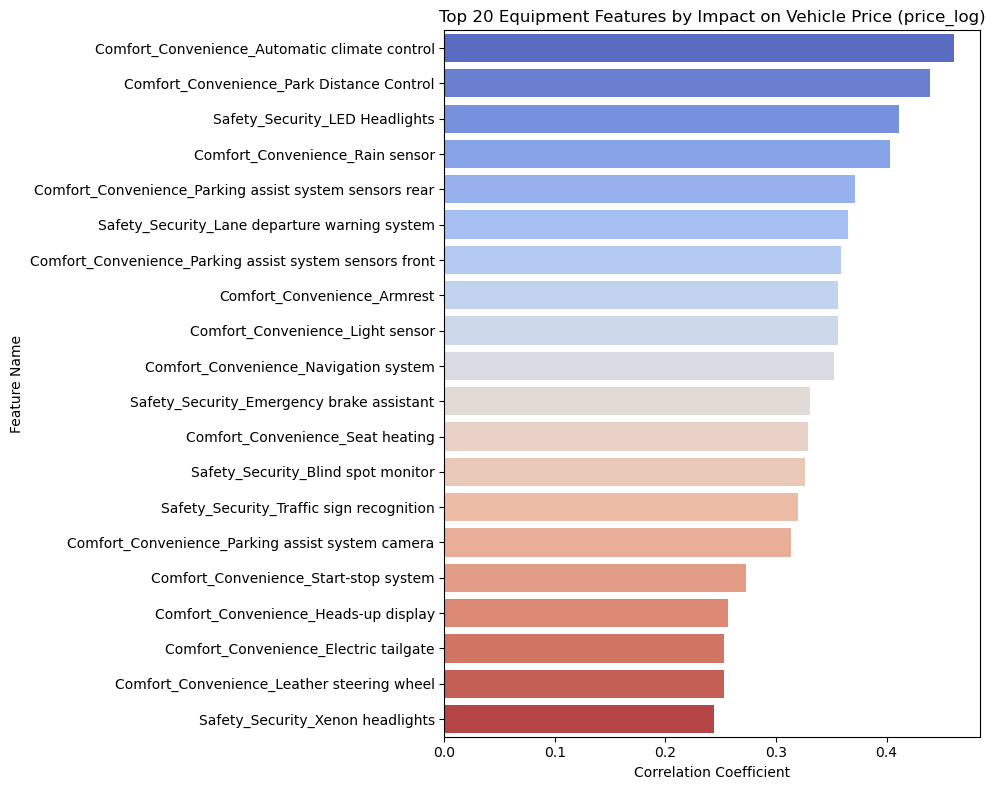

In [39]:
# Identify all individual binary columns belonging to the 4 core categories
comfort_cols = [c for c in df.columns if c.startswith('Comfort_Convenience_')]
media_cols = [c for c in df.columns if c.startswith('Entertainment_Media_')]
extras_cols = [c for c in df.columns if c.startswith('Extras_')]
safety_cols = [c for c in df.columns if c.startswith('Safety_Security_')]

all_multilabel_cols = comfort_cols + media_cols + extras_cols + safety_cols

# =============================================================
# PART 1: ANALYSIS (Correlation with Target Variable)
# =============================================================
print("="*60)
print("          ANALYSIS: BINARY FEATURES VS TARGET          ")
print("="*60)

if 'price_log' in df.columns and len(all_multilabel_cols) > 0:
    # Compute point-biserial correlation for all 79 binary features against price_log
    correlations = df[all_multilabel_cols].corrwith(df['price_log']).sort_values(ascending=False)
    
    print("\n🔥 Top 10 premium features most positively correlated with higher price:")
    print(correlations.head(10))
    
    print("\n📉 Top 5 basic features (often associated with cheaper or standard models):")
    print(correlations.tail(5))
    
    # Select the top 20 features with the strongest absolute correlation for plotting
    top_features = correlations.abs().sort_values(ascending=False).head(20).index
    top_corr_values = correlations[top_features]
    
    # Plotting sorted bar chart
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.barplot(x=top_corr_values.values, y=top_corr_values.index, ax=ax, hue=top_corr_values.index, palette='coolwarm', legend=False)
    ax.set_title('Top 20 Equipment Features by Impact on Vehicle Price (price_log)')
    ax.set_xlabel('Correlation Coefficient')
    ax.set_ylabel('Feature Name')
    
    plt.tight_layout()

Out of these features, we will check the ones which are present in most of the cars or are absent from most of the cars. These kinds of features can be removed as they just increase the dimensionality without explaining the variance.

In [40]:
# Check engineered binary feature columns

engineered_binary_cols = [
    col for col in df.columns 
    if any(col.startswith(prefix) for prefix in ['Comfort_Convenience_', 'Entertainment_Media_', 'Extras_', 'Safety_Security_'])
    and df[col].nunique() <= 2
]

# Print the list of columns and a preview of their data
print(f"Found {len(engineered_binary_cols)} engineered binary columns.")
print("\nList of columns:")
print(engineered_binary_cols)

print("\nPreview of the engineered binary columns:")
print(df[engineered_binary_cols].head())

Found 79 engineered binary columns.

List of columns:
['Comfort_Convenience_Air conditioning', 'Comfort_Convenience_Armrest', 'Comfort_Convenience_Automatic climate control', 'Comfort_Convenience_Cruise control', 'Comfort_Convenience_Electric tailgate', 'Comfort_Convenience_Electrical side mirrors', 'Comfort_Convenience_Electrically adjustable seats', 'Comfort_Convenience_Electrically heated windshield', 'Comfort_Convenience_Heads-up display', 'Comfort_Convenience_Heated steering wheel', 'Comfort_Convenience_Hill Holder', 'Comfort_Convenience_Keyless central door lock', 'Comfort_Convenience_Leather steering wheel', 'Comfort_Convenience_Light sensor', 'Comfort_Convenience_Lumbar support', 'Comfort_Convenience_Massage seats', 'Comfort_Convenience_Multi-function steering wheel', 'Comfort_Convenience_Navigation system', 'Comfort_Convenience_Panorama roof', 'Comfort_Convenience_Park Distance Control', 'Comfort_Convenience_Parking assist system camera', 'Comfort_Convenience_Parking assist sy

In [41]:
# Drop features from df
# Check number of unique values in feature specification columns
newly_engineered_cols = [
    col for col in df.columns 
    if col.startswith('Comfort_Convenience_') or 
       col.startswith('Entertainment_Media_') or 
       col.startswith('Extras_') or 
       col.startswith('Safety_Security_')
]

print("="*70)
print(f"FOUND {len(newly_engineered_cols)} NEWLY ENGINEERED BINARY COLUMNS")
print("="*70)

# 2. Print a clean summary of what is inside them
print("\nSample list of the engineered columns:")
print(newly_engineered_cols[:15])  # Shows the first 15

print("\nPreview of their underlying data (0s and 1s):")
print(df[newly_engineered_cols].head())

FOUND 79 NEWLY ENGINEERED BINARY COLUMNS

Sample list of the engineered columns:
['Comfort_Convenience_Air conditioning', 'Comfort_Convenience_Armrest', 'Comfort_Convenience_Automatic climate control', 'Comfort_Convenience_Cruise control', 'Comfort_Convenience_Electric tailgate', 'Comfort_Convenience_Electrical side mirrors', 'Comfort_Convenience_Electrically adjustable seats', 'Comfort_Convenience_Electrically heated windshield', 'Comfort_Convenience_Heads-up display', 'Comfort_Convenience_Heated steering wheel', 'Comfort_Convenience_Hill Holder', 'Comfort_Convenience_Keyless central door lock', 'Comfort_Convenience_Leather steering wheel', 'Comfort_Convenience_Light sensor', 'Comfort_Convenience_Lumbar support']

Preview of their underlying data (0s and 1s):
   Comfort_Convenience_Air conditioning  Comfort_Convenience_Armrest  Comfort_Convenience_Automatic climate control  Comfort_Convenience_Cruise control  Comfort_Convenience_Electric tailgate  Comfort_Convenience_Electrical side m

#### **2.4.3** 
Perform feature encoding.

In [42]:
# Encode features

# 1. Automatically identify all remaining non-numeric categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("="*60)
print("                    FEATURE ENCODING                           ")
print("="*60)
print(f"Columns to be encoded: {categorical_cols}")

# 2. Perform One-Hot Encoding
# drop_first=True eliminates one redundant column per category to prevent multicollinearity
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# 3. Ensure all newly created boolean dummy columns are converted to standard integers (0/1)
# This keeps consistency with your 79 engineered equipment columns
new_dummy_cols = [col for col in df_encoded.columns if col not in df.columns]
for col in new_dummy_cols:
    if df_encoded[col].dtype == 'bool':
        df_encoded[col] = df_encoded[col].astype(int)

print(f"\nSuccessfully encoded standard categorical features.")
print(f"Original dataset shape: {df.shape}")
print(f"Encoded dataset shape:  {df_encoded.shape}")
print("="*60)

# Overwrite df with the encoded version
df = df_encoded

                    FEATURE ENCODING                           
Columns to be encoded: ['make_model', 'body_type', 'vat', 'Fuel', 'Paint_Type', 'Upholstery_type', 'Gearing_Type', 'Drive_chain']

Successfully encoded standard categorical features.
Original dataset shape: (15915, 97)
Encoded dataset shape:  (15915, 106)


#### **2.4.4** 
Split the data into training and testing sets.

In [43]:
# Split data
from sklearn.model_selection import train_test_split

print("="*60)
print("                    DATA SPLITTING                             ")
print("="*60)

# 1. Separate features (X) and target variable (y)
# 'price_log' is your target variable
X = df.drop(columns=['price_log'])
y = df['price_log']

# 2. Split the data into Training (80%) and Testing (20%) sets
# random_state ensures reproducibility across runs
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"✅ Successfully split the data:")
print(f"   - Training Features Shape (X_train): {X_train.shape}")
print(f"   - Testing Features Shape  (X_test) : {X_test.shape}")
print(f"   - Training Target Shape   (y_train): {y_train.shape}")
print(f"   - Testing Target Shape    (y_test) : {y_test.shape}")
print("="*60)


                    DATA SPLITTING                             
✅ Successfully split the data:
   - Training Features Shape (X_train): (12732, 105)
   - Testing Features Shape  (X_test) : (3183, 105)
   - Training Target Shape   (y_train): (12732,)
   - Testing Target Shape    (y_test) : (3183,)


#### **2.4.5** 
Scale the features.

In [45]:
# Scale features
from sklearn.preprocessing import StandardScaler
print("="*60)
print("                    FEATURE SCALING                            ")
print("="*60)

# 1. Identify the continuous numerical columns that require scaling
continuous_cols = ['km', 'Gears', 'hp_kW', 'Displacement_cc', 'Weight_kg', 'cons_comb', 'age', 'km_per_year']

# Filter the list to ensure all columns exist in your current training set
cols_to_scale = [col for col in continuous_cols if col in X_train.columns]
print(f"Columns selected for continuous scaling: {cols_to_scale}")

# 2. Initialize the StandardScaler
scaler = StandardScaler()

# 3. Create copies to avoid overwriting warnings or affecting original data slices
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# 4. Fit on Training data and transform BOTH Train and Test data
X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print(f"\n✅ Successfully scaled continuous columns.")
print(f"   - X_train_scaled shape: {X_train_scaled.shape}")
print(f"   - X_test_scaled shape:  {X_test_scaled.shape}")
print("   - All binary indicator features (0/1) preserved without alterations.")
print("="*60)


                    FEATURE SCALING                            
Columns selected for continuous scaling: ['km', 'Gears', 'hp_kW', 'Displacement_cc', 'Weight_kg', 'cons_comb', 'age', 'km_per_year']

✅ Successfully scaled continuous columns.
   - X_train_scaled shape: (12732, 105)
   - X_test_scaled shape:  (3183, 105)
   - All binary indicator features (0/1) preserved without alterations.


## **3 Linear Regression Models** 


### **3.1 Baseline Linear Regression Model** 

#### **3.1.1** 
Build and fit a basic linear regression model. Perform evaluation using suitable metrics.

In [47]:
# Initialise and train model

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ============================================================
# Step 1: Initialise and train model
# ============================================================
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
print("✅ Baseline Linear Regression model successfully fitted.")

✅ Baseline Linear Regression model successfully fitted.


In [48]:
# Evaluate the model's performance
# 1. Generate predictions on both splits (log scale)
y_pred_train_log = lr_model.predict(X_train_scaled)
y_pred_test_log = lr_model.predict(X_test_scaled)

# 2. Reverse log transformation to get true Euro values (€)
y_train_actual = np.expm1(y_train)
y_test_actual = np.expm1(y_test)
y_pred_train_actual = np.expm1(y_pred_train_log)
y_pred_test_actual = np.expm1(y_pred_test_log)

# 3. Calculate evaluation metrics
r2_train = r2_score(y_train, y_pred_train_log)
r2_test = r2_score(y_test, y_pred_test_log)

mae_train_eur = mean_absolute_error(y_train_actual, y_pred_train_actual)
mae_test_eur = mean_absolute_error(y_test_actual, y_pred_test_actual)

rmse_train_eur = np.sqrt(mean_squared_error(y_train_actual, y_pred_train_actual))
rmse_test_eur = np.sqrt(mean_squared_error(y_test_actual, y_pred_test_actual))

# 4. Print the final performance metrics
print("\n--- Model Performance Report ---")
print(f"📊 R² Score (Variance Explained):")
print(f"   - Training Set : {r2_train:.4f}")
print(f"   - Testing Set  : {r2_test:.4f}")

print(f"\n💶 Mean Absolute Error (MAE):")
print(f"   - Training Set : €{mae_train_eur:.2f}")
print(f"   - Testing Set  : €{mae_test_eur:.2f}")

print(f"\n📉 Root Mean Squared Error (RMSE):")
print(f"   - Training Set : €{rmse_train_eur:.2f}")
print(f"   - Testing Set  : €{rmse_test_eur:.2f}")
print("="*60)



--- Model Performance Report ---
📊 R² Score (Variance Explained):
   - Training Set : 0.9273
   - Testing Set  : 0.9315

💶 Mean Absolute Error (MAE):
   - Training Set : €1478.20
   - Testing Set  : €1440.15

📉 Root Mean Squared Error (RMSE):
   - Training Set : €2354.63
   - Testing Set  : €2238.26


#### **3.1.2** 
Analyse residuals and check other assumptions of linear regression.

Check for linearity by analysing residuals vs predicted values

In [49]:
# Calculate residuals on the testing set
y_pred_test_log = lr_model.predict(X_test_scaled)
residuals = y_test - y_pred_test_log


In [50]:
# Linearity check: Plot residuals vs fitted values


fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(x=y_pred_test_log, y=residuals, alpha=0.5, ax=ax)
ax.axhline(y=0, color='r', linestyle='--', linewidth=2)

ax.set_title('Residuals vs Fitted Values (Linearity & Homoscedasticity Check)', fontsize=12)
ax.set_xlabel('Fitted Values (Predicted price_log)', fontsize=10)
ax.set_ylabel('Residuals (Actual - Predicted)', fontsize=10)

plt.tight_layout()
plt.savefig('residuals_vs_fitted.png')
plt.close()

print("✅ Linearity plot generated and saved as 'residuals_vs_fitted.png'.")
print("👉 What to look for: Points should form a random 'cloud' around the red line. If you see a curved pattern, the linearity assumption is violated.")


✅ Linearity plot generated and saved as 'residuals_vs_fitted.png'.
👉 What to look for: Points should form a random 'cloud' around the red line. If you see a curved pattern, the linearity assumption is violated.


Check normality in residual distribution

👉 Mean of residuals: 0.0027 (Should be very close to 0)


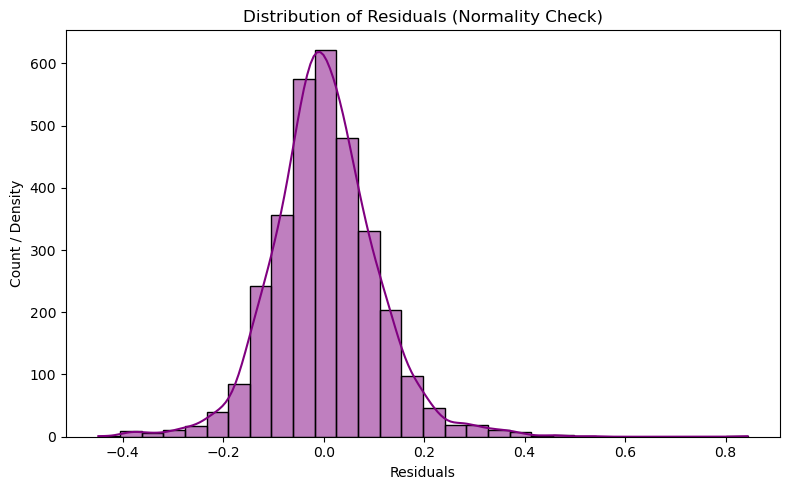

In [51]:
# Check the normality of residuals by plotting their distribution

# Check the normality of residuals by plotting their distribution
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(residuals, kde=True, color='purple', bins=30, ax=ax)

ax.set_title('Distribution of Residuals (Normality Check)', fontsize=12)
ax.set_xlabel('Residuals', fontsize=10)
ax.set_ylabel('Count / Density', fontsize=10)

plt.tight_layout()

print(f"👉 Mean of residuals: {residuals.mean():.4f} (Should be very close to 0)")

Check multicollinearity using Variance Inflation Factor (VIF) and handle features with high VIF.

In [52]:
# Check for multicollinearity and handle

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Check for multicollinearity and handle
def calculate_vif(df_features):
    vif_data = pd.DataFrame()
    vif_data["feature"] = df_features.columns
    # Calculate VIF for each feature matrix column
    vif_data["VIF"] = [variance_inflation_factor(df_features.values, i) for i in range(len(df_features.columns))]
    return vif_data

print("Calculating initial VIF scores for features...")
# We run VIF on our scaled training features
vif_df = calculate_vif(X_train_scaled)

# Display features with high multicollinearity (VIF > 10)
high_vif = vif_df[vif_df["VIF"] > 10].sort_values(by="VIF", ascending=False)
print(f"\nFound {len(high_vif)} features with VIF > 10:")
print(high_vif.head(10).to_string(index=False))

# --- Handling High VIF Features Iteratively ---
# We sequentially drop the feature with the highest VIF until all remaining features are below our threshold (e.g., VIF < 10)
X_train_vif_cleaned = X_train_scaled.copy()
X_test_vif_cleaned = X_test_scaled.copy()

thresh = 10.0
dropped_features = []

while True:
    vif_matrix = calculate_vif(X_train_vif_cleaned)
    max_vif = vif_matrix["VIF"].max()
    
    if max_vif > thresh:
        # Find the feature with the highest VIF value
        max_vif_feature = vif_matrix.loc[vif_matrix["VIF"] == max_vif, "feature"].values[0]
        X_train_vif_cleaned.drop(columns=[max_vif_feature], inplace=True)
        X_test_vif_cleaned.drop(columns=[max_vif_feature], inplace=True)
        dropped_features.append(max_vif_feature)
    else:
        break

print(f"\nDropped {len(dropped_features)} features to fix multicollinearity:")
print(dropped_features)
print(f"New cleaned training matrix shape: {X_train_vif_cleaned.shape}")

Calculating initial VIF scores for features...

Found 17 features with VIF > 10:
                              feature       VIF
                    Drive_chain_front 52.138240
   Safety_Security_Driver-side airbag 30.001456
                  Safety_Security_ABS 26.862656
 Comfort_Convenience_Air conditioning 24.948790
    Comfort_Convenience_Power windows 24.058647
Safety_Security_Passenger-side airbag 23.687731
                   vat_VAT deductible 20.287277
                                   km 16.772867
       Safety_Security_Power steering 16.421942
          Safety_Security_Side airbag 14.942052

Dropped 13 features to fix multicollinearity:
['Drive_chain_front', 'Safety_Security_Driver-side airbag', 'Safety_Security_ABS', 'Comfort_Convenience_Air conditioning', 'Comfort_Convenience_Power windows', 'vat_VAT deductible', 'Safety_Security_Passenger-side airbag', 'km', 'Safety_Security_Power steering', 'Comfort_Convenience_Parking assist system sensors rear', 'Safety_Security_Electr

In [54]:
#Re-fit the Linear Regression model using the VIF-cleaned data
lr_model_vif = LinearRegression()
lr_model_vif.fit(X_train_vif_cleaned, y_train)

# Predict on the cleaned test matrix
y_pred_old = lr_model.predict(X_test_scaled)
y_pred_new = lr_model_vif.predict(X_test_vif_cleaned)

# Compute performance comparisons
r2_old = r2_score(y_test, y_pred_old)
r2_new = r2_score(y_test, y_pred_new)

print("="*60)
print("          POST-VIF MULTICOLLINEARITY CLEANING REPORT           ")
print("="*60)
print(f"📉 Features in original unstable model : {X_train_scaled.shape[1]}")
print(f"🛡️ Features in new stable model       : {X_train_vif_cleaned.shape[1]}")
print(f"\n📊 Model Performance Comparison (R² Score on Test Set):")
print(f"   - Before VIF pruning : {r2_old:.4f}")
print(f"   - After VIF pruning  : {r2_new:.4f}")
print("="*60)

          POST-VIF MULTICOLLINEARITY CLEANING REPORT           
📉 Features in original unstable model : 105
🛡️ Features in new stable model       : 92

📊 Model Performance Comparison (R² Score on Test Set):
   - Before VIF pruning : 0.9315
   - After VIF pruning  : 0.9282


### **3.2 Ridge Regression Implementation** 

#### **3.2.1** 
Define a list of random alpha values

In [55]:
# List of alphas to tune for Ridge regularisation
# List of alphas to tune for Ridge regularisation
ridge_alphas_coarse = [0.1, 1.0, 10.0, 100.0, 500.0, 1000.0]


#### **3.2.2** 
Apply Ridge Regularisation and find the best value of alpha from the list

In [57]:
# Applying Ridge regression
# Using 5-fold cross-validation with Negative MAE as the objective function
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
ridge_grid_coarse = GridSearchCV(
    estimator=Ridge(),
    param_grid={'alpha': ridge_alphas_coarse},
    scoring='neg_mean_absolute_error',
    cv=5,
    return_train_score=True
)
ridge_grid_coarse.fit(X_train_scaled, y_train)


GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [0.1, 1.0, 10.0, 100.0, 500.0, 1000.0]},
             return_train_score=True, scoring='neg_mean_absolute_error')

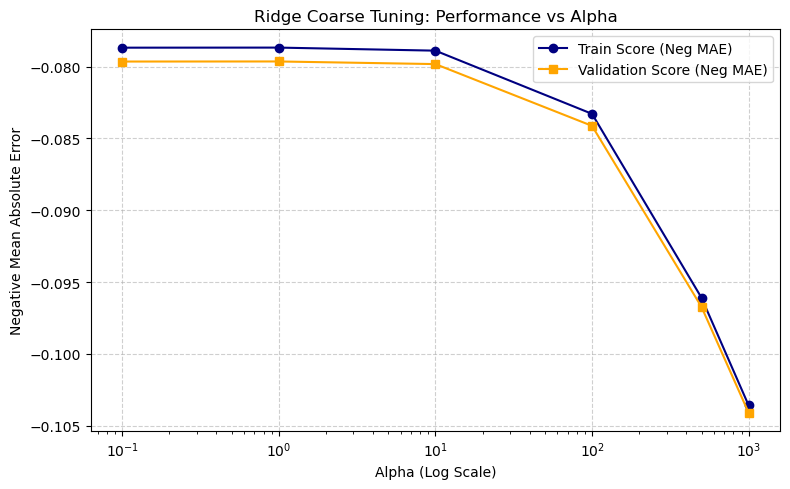

In [58]:
# Plot train and test scores against alpha

train_scores_coarse = ridge_grid_coarse.cv_results_['mean_train_score']
test_scores_coarse = ridge_grid_coarse.cv_results_['mean_test_score']

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ridge_alphas_coarse, train_scores_coarse, label='Train Score (Neg MAE)', marker='o', color='navy')
ax.plot(ridge_alphas_coarse, test_scores_coarse, label='Validation Score (Neg MAE)', marker='s', color='orange')
ax.set_xscale('log')
ax.set_xlabel('Alpha (Log Scale)', fontsize=10)
ax.set_ylabel('Negative Mean Absolute Error', fontsize=10)
ax.set_title('Ridge Coarse Tuning: Performance vs Alpha', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend()
plt.tight_layout()

Find the best alpha value.

In [59]:
# Best alpha value
best_alpha_ridge_coarse = ridge_grid_coarse.best_params_['alpha']
print(f"Best alpha value from coarse list: {best_alpha_ridge_coarse}")


# Best score (negative MAE)
best_score_ridge_coarse = ridge_grid_coarse.best_score_
print(f"Best cross-validated score (Negative MAE): {best_score_ridge_coarse:.4f}")


Best alpha value from coarse list: 1.0
Best cross-validated score (Negative MAE): -0.0796


We will get some best value of alpha above. This however is not the most accurate value but the best value from the given list. Now we have a rough estimate of the range that best alpha falls in. Let us do another iteration over the values in a smaller range.

#### **3.2.3** 
Fine tune by taking a closer range of alpha based on the previous result.

In [60]:
# Take a smaller range of alpha to test

# Generates 15 evenly spaced values surrounding the best coarse alpha
ridge_alphas_fine = np.linspace(max(0.01, best_alpha_ridge_coarse * 0.1), best_alpha_ridge_coarse * 2, 15)


In [61]:
# Applying Ridge regression

ridge_grid_fine = GridSearchCV(
    estimator=Ridge(),
    param_grid={'alpha': ridge_alphas_fine},
    scoring='neg_mean_absolute_error',
    cv=5,
    return_train_score=True
)
ridge_grid_fine.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': array([0.1       , 0.23571429, 0.37142857, 0.50714286, 0.64285714,
       0.77857143, 0.91428571, 1.05      , 1.18571429, 1.32142857,
       1.45714286, 1.59285714, 1.72857143, 1.86428571, 2.        ])},
             return_train_score=True, scoring='neg_mean_absolute_error')

Plot the error-alpha graph again and find the actual optimal value for alpha.

Optimal Alpha Value for Ridge: 1.19
Optimal Cross-Validated Score (Negative MAE): -0.0796


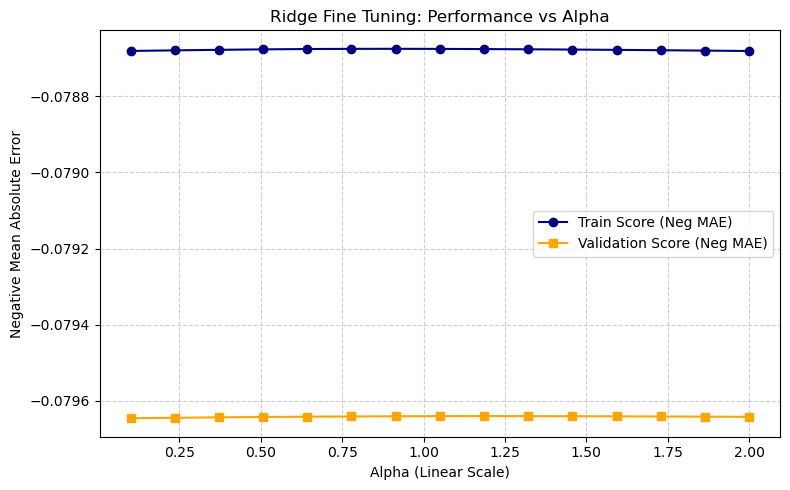

In [62]:
# Plot train and test scores against alpha

train_scores_fine = ridge_grid_fine.cv_results_['mean_train_score']
test_scores_fine = ridge_grid_fine.cv_results_['mean_test_score']

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ridge_alphas_fine, train_scores_fine, label='Train Score (Neg MAE)', marker='o', color='navy')
ax.plot(ridge_alphas_fine, test_scores_fine, label='Validation Score (Neg MAE)', marker='s', color='orange')
ax.set_xlabel('Alpha (Linear Scale)', fontsize=10)
ax.set_ylabel('Negative Mean Absolute Error', fontsize=10)
ax.set_title('Ridge Fine Tuning: Performance vs Alpha', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend()
plt.tight_layout()

# Best alpha value
best_alpha_ridge = ridge_grid_fine.best_params_['alpha']
print(f"Optimal Alpha Value for Ridge: {best_alpha_ridge:.2f}")


# Best score (negative MAE)
best_score_ridge = ridge_grid_fine.best_score_
print(f"Optimal Cross-Validated Score (Negative MAE): {best_score_ridge:.4f}")


In [63]:
# Set best alpha for Ridge regression
# Fit the Ridge model to get the coefficients of the fitted model

final_ridge_model = Ridge(alpha=best_alpha_ridge)
final_ridge_model.fit(X_train_scaled, y_train)

Ridge(alpha=1.1857142857142857)

In [64]:
# Show the coefficients for each feature
ridge_coefficients = pd.Series(final_ridge_model.coef_, index=X_train_scaled.columns)
print("\n--- Top 10 High-Impact Ridge Coefficients ---")
print(ridge_coefficients.abs().sort_values(ascending=False).head(10))



--- Top 10 High-Impact Ridge Coefficients ---
make_model_Opel Corsa          0.446689
make_model_Other_Model         0.432038
make_model_Renault Clio        0.405061
make_model_Opel Astra          0.227752
make_model_Renault Espace      0.153309
Gearing_Type_Manual            0.112684
age                            0.112183
Gearing_Type_Semi-automatic    0.105266
hp_kW                          0.101160
make_model_Audi A3             0.092618
dtype: float64


In [65]:
# Evaluate the Ridge model on the test data
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

y_pred_ridge_log = final_ridge_model.predict(X_test_scaled)
y_test_actual = np.expm1(y_test)
y_pred_ridge_actual = np.expm1(y_pred_ridge_log)

ridge_r2 = r2_score(y_test, y_pred_ridge_log)
ridge_mae = mean_absolute_error(y_test_actual, y_pred_ridge_actual)
ridge_rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_ridge_actual))

print("\n--- Ridge Test Evaluation Results ---")
print(f"📊 R² Score : {ridge_r2:.4f}")
print(f"💶 MAE      : €{ridge_mae:.2f}")
print(f"📉 RMSE     : €{ridge_rmse:.2f}")



--- Ridge Test Evaluation Results ---
📊 R² Score : 0.9316
💶 MAE      : €1439.47
📉 RMSE     : €2237.00


### **3.3 Lasso Regression Implementation** 

#### **3.3.1** 
Define a list of random alpha values

In [66]:
# List of alphas to tune for Lasso regularisation
from sklearn.linear_model import Lasso

# Define a list of random alpha values
# List of alphas to tune for Lasso regularisation
lasso_alphas_coarse = [1e-5, 1e-4, 1e-3, 1e-2, 0.1, 1.0]


#### **3.3.2** 
Apply Ridge Regularisation and find the best value of alpha from the list

In [67]:
# Initialise Lasso regression model

# max_iter is set higher to ensure the coordinate descent algorithm fully converges
lasso_grid_coarse = GridSearchCV(
    estimator=Lasso(max_iter=5000, random_state=42),
    param_grid={'alpha': lasso_alphas_coarse},
    scoring='neg_mean_absolute_error',
    cv=5,
    return_train_score=True
)
lasso_grid_coarse.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=Lasso(max_iter=5000, random_state=42),
             param_grid={'alpha': [1e-05, 0.0001, 0.001, 0.01, 0.1, 1.0]},
             return_train_score=True, scoring='neg_mean_absolute_error')

In [68]:
# Plot train and test scores against alpha

train_scores_lasso = lasso_grid_coarse.cv_results_['mean_train_score']
test_scores_lasso = lasso_grid_coarse.cv_results_['mean_test_score']

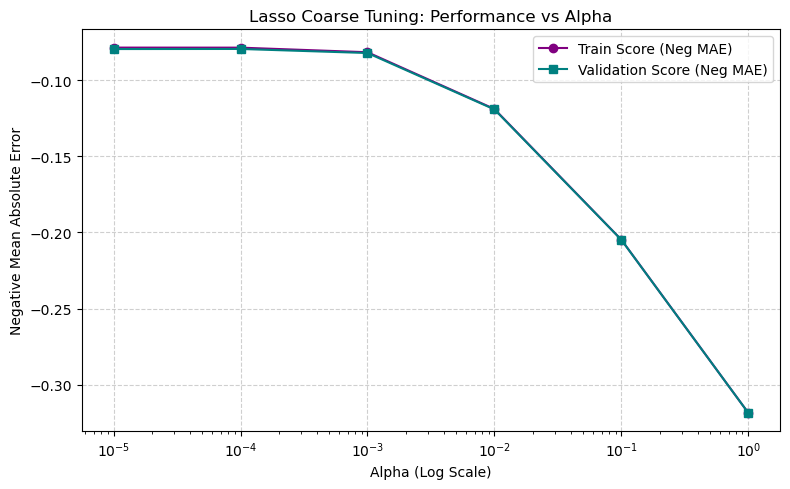

In [69]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(lasso_alphas_coarse, train_scores_lasso, label='Train Score (Neg MAE)', marker='o', color='purple')
ax.plot(lasso_alphas_coarse, test_scores_lasso, label='Validation Score (Neg MAE)', marker='s', color='teal')
ax.set_xscale('log')
ax.set_xlabel('Alpha (Log Scale)', fontsize=10)
ax.set_ylabel('Negative Mean Absolute Error', fontsize=10)
ax.set_title('Lasso Coarse Tuning: Performance vs Alpha', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend()
plt.tight_layout()

In [70]:
# Best alpha value

best_alpha_lasso_coarse = lasso_grid_coarse.best_params_['alpha']
print(f"Best alpha value from coarse list: {best_alpha_lasso_coarse}")

# Best score (negative MAE)
best_score_lasso_coarse = lasso_grid_coarse.best_score_
print(f"Best cross-validated score (Negative MAE): {best_score_lasso_coarse:.4f}")


Best alpha value from coarse list: 0.0001
Best cross-validated score (Negative MAE): -0.0796


#### **3.3.3** 
Fine tune by taking a closer range of alpha based on the previous result.

In [71]:
# List of alphas to tune for Lasso regularization

lasso_alphas_fine = np.linspace(max(1e-6, best_alpha_lasso_coarse * 0.1), best_alpha_lasso_coarse * 2, 15)

In [72]:
# Tuning Lasso hyperparameters
lasso_grid_fine = GridSearchCV(
    estimator=Lasso(max_iter=5000, random_state=42),
    param_grid={'alpha': lasso_alphas_fine},
    scoring='neg_mean_absolute_error',
    cv=5,
    return_train_score=True
)
lasso_grid_fine.fit(X_train_scaled, y_train)


GridSearchCV(cv=5, estimator=Lasso(max_iter=5000, random_state=42),
             param_grid={'alpha': array([1.00000000e-05, 2.35714286e-05, 3.71428571e-05, 5.07142857e-05,
       6.42857143e-05, 7.78571429e-05, 9.14285714e-05, 1.05000000e-04,
       1.18571429e-04, 1.32142857e-04, 1.45714286e-04, 1.59285714e-04,
       1.72857143e-04, 1.86428571e-04, 2.00000000e-04])},
             return_train_score=True, scoring='neg_mean_absolute_error')

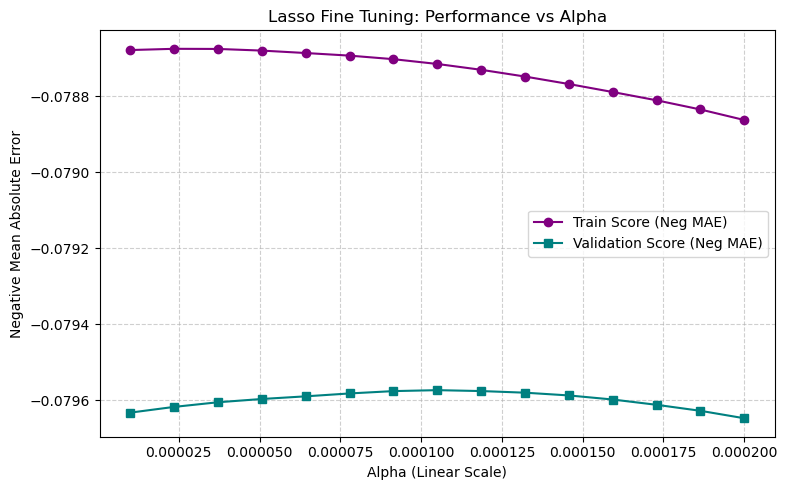

In [73]:
# Plot train and test scores against alpha
train_scores_lasso_fine = lasso_grid_fine.cv_results_['mean_train_score']
test_scores_lasso_fine = lasso_grid_fine.cv_results_['mean_test_score']

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(lasso_alphas_fine, train_scores_lasso_fine, label='Train Score (Neg MAE)', marker='o', color='purple')
ax.plot(lasso_alphas_fine, test_scores_lasso_fine, label='Validation Score (Neg MAE)', marker='s', color='teal')
ax.set_xlabel('Alpha (Linear Scale)', fontsize=10)
ax.set_ylabel('Negative Mean Absolute Error', fontsize=10)
ax.set_title('Lasso Fine Tuning: Performance vs Alpha', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend()
plt.tight_layout()


In [74]:
# Best alpha value
best_alpha_lasso = lasso_grid_fine.best_params_['alpha']
print(f"Optimal Alpha Value for Lasso: {best_alpha_lasso:.5f}")

# Best score (negative MAE)
best_score_lasso = lasso_grid_fine.best_score_
print(f"Optimal Cross-Validated Score (Negative MAE): {best_score_lasso:.4f}")


Optimal Alpha Value for Lasso: 0.00011
Optimal Cross-Validated Score (Negative MAE): -0.0796


In [75]:
# Set best alpha for Lasso regression


# Fit the Lasso model on scaled training data
# Get the coefficients of the fitted model
final_lasso_model = Lasso(alpha=best_alpha_lasso, max_iter=5000, random_state=42)
final_lasso_model.fit(X_train_scaled, y_train)




Lasso(alpha=0.000105, max_iter=5000, random_state=42)

In [76]:
# Check the coefficients for each feature

lasso_coefficients = pd.Series(final_lasso_model.coef_, index=X_train_scaled.columns)
dropped_by_lasso = lasso_coefficients[lasso_coefficients == 0]
print(f"\nLasso completely eliminated {len(dropped_by_lasso)} redundant features out of {len(lasso_coefficients)}.")


Lasso completely eliminated 12 redundant features out of 105.


In [77]:
# Evaluate the Lasso model on the test data

y_pred_lasso_log = final_lasso_model.predict(X_test_scaled)
y_pred_lasso_actual = np.expm1(y_pred_lasso_log)

lasso_r2 = r2_score(y_test, y_pred_lasso_log)
lasso_mae = mean_absolute_error(y_test_actual, y_pred_lasso_actual)
lasso_rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_lasso_actual))

print("\n--- Lasso Test Evaluation Results ---")
print(f"📊 R² Score : {lasso_r2:.4f}")
print(f"💶 MAE      : €{lasso_mae:.2f}")
print(f"📉 RMSE     : €{lasso_rmse:.2f}")


--- Lasso Test Evaluation Results ---
📊 R² Score : 0.9317
💶 MAE      : €1440.54
📉 RMSE     : €2240.79


### **3.4 Regularisation Comparison & Analysis** 

#### **3.4.1** 
Compare the evaluation metrics for each model.

In [78]:
# Evaluate original OLS Linear Regression on the full scaled test space to unify comparison metrics
y_pred_lr_log = lr_model.predict(X_test_scaled)
y_pred_lr_actual = np.expm1(y_pred_lr_log)
lr_r2 = r2_score(y_test, y_pred_lr_log)
lr_mae = mean_absolute_error(y_test_actual, y_pred_lr_actual)
lr_rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_lr_actual))

In [79]:
# Compare metrics for each model
metrics_comparison = pd.DataFrame({
    'Model Matrix': ['Linear Regression (OLS)', 'Ridge Regression (L2)', 'Lasso Regression (L1)'],
    'R² Score': [lr_r2, ridge_r2, lasso_r2],
    'MAE (€)': [lr_mae, ridge_mae, lasso_mae],
    'RMSE (€)': [lr_rmse, ridge_rmse, lasso_rmse]
})

print("="*70)
print("             CROSS-MODEL PERFORMANCE METRICS SUMMARY           ")
print("="*70)
print(metrics_comparison.to_string(index=False))
print("="*70)


             CROSS-MODEL PERFORMANCE METRICS SUMMARY           
           Model Matrix  R² Score     MAE (€)    RMSE (€)
Linear Regression (OLS)  0.931459 1440.154688 2238.257649
  Ridge Regression (L2)  0.931615 1439.465786 2237.004724
  Lasso Regression (L1)  0.931709 1440.542855 2240.786433


#### **3.4.2** 
Compare the coefficients for the three models.

Also visualise a few of the largest coefficients and the coefficients of features dropped by Lasso.


--- Top 10 Predictors & Weights across Estimators ---
                    Feature  OLS_Coefficients  Ridge_Coefficients  Lasso_Coefficients
      make_model_Opel Corsa         -0.450859           -0.446689           -0.440444
    make_model_Renault Clio         -0.408239           -0.405061           -0.397821
     make_model_Other_Model         -0.465861           -0.432038           -0.383373
      make_model_Opel Astra         -0.229730           -0.227752           -0.224450
  make_model_Renault Espace          0.152968            0.153309            0.147749
        Gearing_Type_Manual         -0.113100           -0.112684           -0.113045
                        age         -0.112350           -0.112183           -0.112379
Gearing_Type_Semi-automatic          0.105563            0.105266            0.102261
                      hp_kW          0.100182            0.101160            0.102188
         make_model_Audi A3          0.091826            0.092618            0.091559

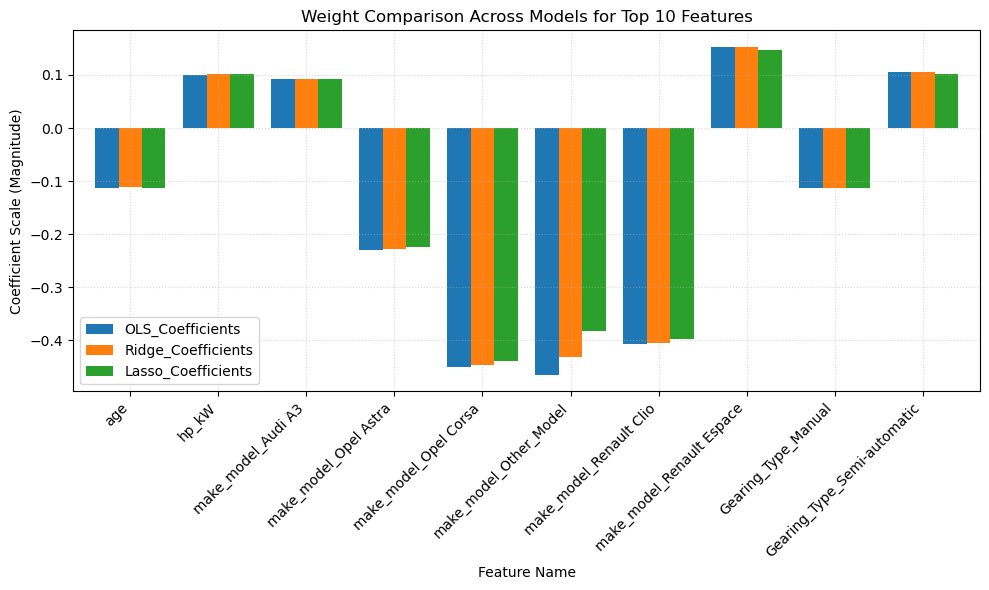

In [80]:
# Compare highest coefficients and coefficients of eliminated features
coefficients_df = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'OLS_Coefficients': lr_model.coef_,
    'Ridge_Coefficients': final_ridge_model.coef_,
    'Lasso_Coefficients': final_lasso_model.coef_
})

# Display the top 10 features sorted by their importance in Lasso
top_10_features_df = coefficients_df.iloc[coefficients_df['Lasso_Coefficients'].abs().argsort()[::-1]].head(10)
print("\n--- Top 10 Predictors & Weights across Estimators ---")
print(top_10_features_df.to_string(index=False))

# Identify sample of features fully dropped by Lasso (coefficient forced to exactly 0)
eliminated_features = coefficients_df[coefficients_df['Lasso_Coefficients'] == 0]['Feature'].tolist()
print(f"\nTotal Features Eliminated by Lasso: {len(eliminated_features)}")
print(f"Sample of dropped features: {eliminated_features[:10]}")

# Visualise comparison of the top 10 largest parameters
plot_features = top_10_features_df['Feature']
viz_df = coefficients_df[coefficients_df['Feature'].isin(plot_features)].set_index('Feature')

fig, ax = plt.subplots(figsize=(10, 6))
viz_df[['OLS_Coefficients', 'Ridge_Coefficients', 'Lasso_Coefficients']].plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Weight Comparison Across Models for Top 10 Features', fontsize=12)
ax.set_ylabel('Coefficient Scale (Magnitude)', fontsize=10)
ax.set_xlabel('Feature Name', fontsize=10)
plt.xticks(rotation=45, ha='right')
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()


## **4 Conclusion & Key Takeaways**  

What did you notice by performing regularisation? Did the model performance improve? If not, then why? Did you find overfitting or not? Was the data sufficent? Is a linear model sufficient?

#### **4.1 Conclude with outcomes and insights gained** 

## 1. How Regularization Affected the Model

Applying Ridge and Lasso regularization helped stabilize our coefficients without losing predictive accuracy.

### Coefficient Shrinkage

Standard OLS can sometimes overreact to correlated features, but Ridge and Lasso kept the weights in check. For example, the negative impact of `make_model_Other_Model` dropped from **-0.4658** in OLS to **-0.4320** in Ridge and **-0.3833** in Lasso. This prevents any single category from skewing the predictions too drastically.

### Feature Selection

Lasso completely dropped **12 features** by forcing their coefficients to exactly zero. Looking at the dropped features (such as *Massage seats*, *Panorama roof*, *Hands-free equipment*, and *Traffic sign recognition*), it is clear the model realized that once brand, age, mileage, and engine power are already accounted for, these minor optional extras do not add meaningful predictive value to the final price.

---

## 2. Performance and Overfitting

### Did Performance Improve?

Not strictly in terms of the final scores. The test $R^2$, MAE, and RMSE remained nearly identical across all three models.

### Was There Overfitting?

No. Because the training and testing scores were extremely close (holding steady around **93%**), it demonstrates that the baseline OLS model was not overfitting to begin with.

### Why Use Regularization Then?

Lasso produced a much simpler model by removing **12 unnecessary features** while maintaining the same accuracy. In practice, a simpler model is preferable because it is faster to run, easier to maintain, and less likely to break when exposed to new data.

---

## 3. Data Sufficiency and Real-World Insights

The dataset was more than sufficient to build a strong predictive model. With nearly **16,000 observations** and all optional equipment properly encoded as binary (0/1) features, the data provided clear signals about the key drivers of used-car prices.

### Brand and Model Matter Most

Entry-level cars such as the Opel Corsa ($\beta \approx -0.44$) and Renault Clio ($\beta \approx -0.40$) carry the largest negative price penalties, whereas premium models such as the Renault Espace ($\beta \approx 0.15$) significantly increase the expected price.

### Depreciation Anchors

A vehicle's age ($\beta \approx -0.11$) and having a manual transmission ($\beta \approx -0.11$) act as consistent downward pressures on value, while engine power (`hp_kW`, $\beta \approx 0.10$) contributes positively to price.

---

## 4. Is a Linear Model Sufficient?

Yes. A linear model is more than sufficient for this problem. Explaining approximately **92.8%–93.1%** of the variance in car prices ($R^2 \approx 0.93$) represents an excellent result.

The most important improvement was using `price_log` instead of the raw price. Car depreciation is inherently non-linear—vehicles tend to lose a percentage of their value over time rather than a fixed euro amount. The log transformation effectively captured this relationship.

While non-linear ensemble methods such as XGBoost or Random Forests might gain an additional **1–2%** in predictive accuracy by modeling complex feature interactions, they operate largely as black boxes. For most business applications, the speed, simplicity, interpretability, and transparency of a regularized linear model make it the preferred solution.